## <span style="color:#5B9BD5">Cross-Encoder Based Semantic Retrieval and FAQ Matching System</span>
### <span style="color:#5B9BD5">Conversational AI (AIMLCZG521) — EC-1 Assessment</span>
#### <span style="color:#5B9BD5">Problem Statement 1 | Total Marks: 10</span>

---

### Student Details and Team Contribution

| Field | Details |
|-------|---------|
| **Assignment** | S1_26 — AIMLZG521 Assignment 1, PS1 |
| **Course** | Conversational AI (AIMLCZG521) |
| **Assessment** | EC-1 |
| **Submission Date** | *(Fill in date)* |

<br>
Below is the Team member details and their contributions to the assignment
<br></br>

| Member | BITS ID | Assigned Tasks and Contribution Areas |
|--------|---------|----------------------------------------|
| RAJESH R. SHENOI | 2025AE05200 | **Tasks 1–2:** BPE Tokenizer + Transformer Encoder |
| PARUL MITTAL | 2025AE05198 | **Tasks 3 & 5:** Contextual Embeddings + Dense Retrieval / ANN |
| SIDDHARTH KUCHIMANCHI | 2025AE05199 | **Tasks 4 & 6:** BM25 Sparse Retrieval + Hybrid Retrieval / RRF |
| LAD SHRUTI MUKESHKUMAR | 2025AE05305 | **Tasks 7–8:** Cross-Encoder Re-ranking + Final Evaluation / Production Recommendation |

---

## <span style="color:#5B9BD5">Problem Statement</span>

Build and evaluate a semantic retrieval and FAQ matching system that demonstrates the complete retrieval pipeline:

<div style="display:table; width:max-content; max-width:100%; margin:0 auto; font-family:inherit; color:#17365D; font-size:0.78em; font-weight:600; letter-spacing:0; white-space:nowrap; line-height:1.35; padding:9px 14px; border-left:5px solid #5B9BD5; background-color:#DDEBF7; overflow-x:auto;">
User Query → BM25 Keyword Retrieval → Dense Vector Retrieval → Hybrid Ranking (RRF) → Cross-Encoder Re-ranking → Match Decision
</div>

---

## <span style="color:#5B9BD5">Dataset Details</span>

- **Primary Dataset**: Quora Question-Pairs — [HuggingFace](https://huggingface.co/datasets/sentence-transformers/quora-duplicates)
- **Task**: Duplicate question detection and FAQ matching

---

## <span style="color:#5B9BD5">Tools and Libraries Used</span>

| Library | Purpose |
|---------|---------|
| `torch` / `torch.nn` | Transformer Encoder from scratch |
| `datasets` (HuggingFace) | Quora dataset loading |
| `transformers` | DistilBERT, MiniLM, BGE-small encoder models |
| `sentence-transformers` | Embedding generation |
| `rank_bm25` | BM25 retrieval |
| `faiss` | ANN indices (HNSW, IVF) |
| `cross-encoder` | Cross-encoder re-ranking |
| `numpy`, `pandas` | Data processing |
| `matplotlib`, `seaborn` | Visualizations |
| `sklearn` | Metrics, TF-IDF |

---

## <span style="color:#5B9BD5">Pipeline Overview</span>

<div style="font-family:inherit; color:#263238; font-size:0.95em; line-height:1.35; margin:14px 0; text-align:center;">
    <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 12px; border-left:4px solid #5B9BD5; background:#DDEBF7; text-align:left;"><strong>Tasks 1–2:</strong> BPE Tokenizer → Transformer Encoder</div>
    <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
    <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 12px; border-left:4px solid #ED7D31; background:#FCE4D6; text-align:left;"><strong>Tasks 3–4:</strong> Contextual Embeddings → BM25 Retrieval</div>
    <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
    <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 12px; border-left:4px solid #8064A2; background:#E4DFEC; text-align:left;"><strong>Tasks 5–6:</strong> Dense Retrieval (ANN / FAISS) → Hybrid Ranking (RRF)</div>
    <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
    <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 12px; border-left:4px solid #C55A11; background:#FCE4D6; text-align:left;"><strong>Tasks 7–8:</strong> Cross-Encoder Re-ranking → Match Decision &amp; Final Evaluation</div>
</div>

<style>
span[style*="color:#5B9BD5"],
span[style*="color:#4682B4"] {
  color: #2F75B5 !important;
}

strong,
b {
  color: #A9D18E !important;
}
</style>

## <span style="color:#5B9BD5">Import the Libraries</span>

In [155]:
import random
import time
import warnings
import collections
import math
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss

from collections import defaultdict, Counter
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from rank_bm25 import BM25Okapi

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("SEED =", SEED)
print("All imports successful.")
warnings.filterwarnings("ignore")

SEED = 42
All imports successful.



## <span style="color:#4682B4">Module 1: Tokenization & Transformer Foundations</span>
### <span style="color:#4682B4">Task 1: Byte Pair Encoding (BPE) Tokenizer with Optimization Analysis</span>

### Requirements:
1. Custom BPE tokenizer from scratch (no pre-trained tokenizers)
2. Train on Quora dataset with vocabulary sizes: 2,000 / 5,000 / 10,000
3. Special tokens: `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`
4. Report: vocab size, merge ops, avg tokens/sentence, compression ratio, OOV rate, tokenization speed
5. Optimization analysis: top-10 merge rules, trade-off discussion
6. Demonstrate on 10 sample questions

In [133]:
# ── Task 1.1: Load Quora Dataset ──────────────────────────────────────────────
os.environ["HF_HUB_DISABLE_XET"] = "1"  # Xet backend errors behind corporate proxy

# "pair-class" config gives sentence1/sentence2/label; remap to the
# questions.text / is_duplicate schema used throughout this notebook.
_raw_dataset = load_dataset("sentence-transformers/quora-duplicates", "pair-class", split="train")

def _to_compat_schema(example):
    """Map pair-class dataset rows to the notebook's question-pair schema."""
    return {
        "questions": {"text": [example["sentence1"], example["sentence2"]]},
        "is_duplicate": bool(example["label"]),
    }

dataset = _raw_dataset.map(_to_compat_schema, remove_columns=_raw_dataset.column_names)
print(f"Dataset size: {len(dataset)}")
print("Sample:", dataset[0])

# Use first 50,000 sentences for training the tokenizer
sentences = []
for item in dataset.select(range(50000)):
    sentences.append(item["questions"]["text"][0])
    sentences.append(item["questions"]["text"][1])

sentences = list(set(sentences))  # deduplicate
print(f"\nUnique sentences for training: {len(sentences)}")

Dataset size: 404290
Sample: {'questions': {'text': ['What is the step by step guide to invest in share market in india?', 'What is the step by step guide to invest in share market?']}, 'is_duplicate': False}

Unique sentences for training: 88884


In [134]:
# ── Task 1.2: BPE Tokenizer From Scratch ──────────────────────────────────────

class BPETokenizer:
    """Custom Byte Pair Encoding tokenizer implemented from scratch."""

    SPECIAL_TOKENS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]"]

    def __init__(self, vocab_size: int = 5000):
        """Initialize tokenizer state, vocab containers, and merge tables."""
        self.vocab_size = vocab_size
        self.merges: list[str] = []
        self.vocab: dict[str, int] = {}
        self.inverse_vocab: dict[int, str] = {}
        self._merge_dict: dict[str, str] = {}

    @staticmethod
    def _pair_key(left: str, right: str) -> str:
        """Create a string key for a pair so dictionaries use no tuple keys."""
        return f"{left}|{right}"

    @staticmethod
    def _split_pair(pair: str) -> list[str]:
        """Recover the two symbols stored in a string pair key."""
        return pair.split("|", 1)

    def _word_freq(self, corpus: list[str]) -> dict[str, int]:
        """Count word-symbol lists encoded as space-separated dictionary keys."""
        freq: dict[str, int] = {}
        for sent in corpus:
            for word in sent.lower().split():
                word_key = " ".join(list(word) + ["</w>"])
                freq[word_key] = freq.get(word_key, 0) + 1
        return freq

    @classmethod
    def _count_pairs(cls, word_freq: dict[str, int]) -> Counter:
        """Count adjacent string pair keys weighted by word frequency."""
        pairs: Counter = Counter()
        for word_key, frequency in word_freq.items():
            symbols = word_key.split(" ")
            for index in range(len(symbols) - 1):
                pair = cls._pair_key(symbols[index], symbols[index + 1])
                pairs[pair] += frequency
        return pairs

    @classmethod
    def _merge_word(cls, symbols: list[str], pair: str, merged: str) -> list[str]:
        """Replace every occurrence of a pair in a symbol list."""
        new_symbols: list[str] = []
        index = 0
        while index < len(symbols):
            if index < len(symbols) - 1 and cls._pair_key(symbols[index], symbols[index + 1]) == pair:
                new_symbols.append(merged)
                index += 2
            else:
                new_symbols.append(symbols[index])
                index += 1
        return new_symbols

    def train(self, corpus: list[str]) -> None:
        """Learn BPE merges and build the final tokenizer vocabulary."""
        print(f"\n[BPE] Starting training: {len(corpus):,} sentences; target vocab={self.vocab_size:,}")
        word_freq = self._word_freq(corpus)
        print(f"[BPE] Unique word representations: {len(word_freq):,}")

        char_vocab: set[str] = set()
        for word_key in word_freq:
            char_vocab.update(word_key.split(" "))

        self.vocab = {token: index for index, token in enumerate(self.SPECIAL_TOKENS)}
        for symbol in sorted(char_vocab):
            if symbol not in self.vocab:
                self.vocab[symbol] = len(self.vocab)

        num_merges = max(self.vocab_size - len(self.vocab), 0)
        print(f"[BPE] Initial vocabulary: {len(self.vocab):,} tokens")
        print(f"[BPE] Planned merge operations: {num_merges:,}")

        pair_counts = self._count_pairs(word_freq)
        pair_to_words: dict[str, set[str]] = defaultdict(set)
        for word_key in word_freq:
            symbols = word_key.split(" ")
            for index in range(len(symbols) - 1):
                pair_to_words[self._pair_key(symbols[index], symbols[index + 1])].add(word_key)
        print(f"[BPE] Initial candidate pairs: {len(pair_counts):,}")

        merge_log: list[list] = []
        for merge_index in range(num_merges):
            if not pair_counts:
                print(f"[BPE] Stopped early: no candidate pairs remain at merge {merge_index:,}")
                break

            pair, frequency = pair_counts.most_common(1)[0]
            self.merges.append(pair)
            merge_log.append([pair, frequency])
            left, right = self._split_pair(pair)
            merged_token = left + right
            self._merge_dict[pair] = merged_token
            if merged_token not in self.vocab:
                self.vocab[merged_token] = len(self.vocab)

            affected_words = list(pair_to_words.pop(pair, set()))
            for word_key in affected_words:
                word_count = word_freq.pop(word_key, 0)
                if not word_count:
                    continue
                symbols = word_key.split(" ")

                for index in range(len(symbols) - 1):
                    old_pair = self._pair_key(symbols[index], symbols[index + 1])
                    pair_counts[old_pair] -= word_count
                    if pair_counts[old_pair] <= 0:
                        del pair_counts[old_pair]
                    pair_to_words[old_pair].discard(word_key)

                new_symbols = self._merge_word(symbols, pair, merged_token)
                new_key = " ".join(new_symbols)
                word_freq[new_key] = word_freq.get(new_key, 0) + word_count
                for index in range(len(new_symbols) - 1):
                    new_pair = self._pair_key(new_symbols[index], new_symbols[index + 1])
                    pair_counts[new_pair] += word_count
                    pair_to_words[new_pair].add(new_key)

            if (merge_index + 1) % 500 == 0:
                print(f"[BPE] Merges done: {merge_index + 1:,}/{num_merges:,}; "
                      f"vocab={len(self.vocab):,}; latest pair={pair!r}; frequency={frequency:,}")

        self.inverse_vocab = {index: token for token, index in self.vocab.items()}
        self._merge_freq_log = merge_log
        print(f"[BPE] Training complete. Final vocabulary size: {len(self.vocab):,}")
        print(f"[BPE] Learned merge rules: {len(self.merges):,}")
        print(f"[BPE] Top 5 merges: {[(pair.replace('|', ''), frequency) for pair, frequency in merge_log[:5]]}")

    def _tokenize_word(self, word: str) -> list[str]:
        """Apply learned merge rules to tokenize a single word."""
        symbols = list(word) + ["</w>"]
        for pair in self.merges:
            left, right = self._split_pair(pair)
            index = 0
            while index < len(symbols) - 1:
                if self._pair_key(symbols[index], symbols[index + 1]) == pair:
                    symbols = symbols[:index] + [left + right] + symbols[index + 2:]
                else:
                    index += 1
        return symbols

    def tokenize(self, text: str) -> list[str]:
        """Tokenize text into [CLS], subword tokens, and [SEP]."""
        tokens = ["[CLS]"]
        for word in text.lower().split():
            tokens.extend(self._tokenize_word(word))
        tokens.append("[SEP]")
        return tokens

    def encode(self, text: str) -> list[int]:
        """Convert tokenized text into integer vocabulary IDs."""
        unk_id = self.vocab["[UNK]"]
        return [self.vocab.get(token, unk_id) for token in self.tokenize(text)]

    def decode(self, ids: list[int]) -> str:
        """Reconstruct readable text from token IDs."""
        tokens = [self.inverse_vocab.get(index, "[UNK]") for index in ids]
        return " ".join(token for token in tokens if token not in self.SPECIAL_TOKENS).replace(" </w>", "").strip()

    def compute_metrics(self, test_sentences: list[str]) -> dict:
        """Compute tokenizer quality and speed metrics on held-out sentences."""
        print(f"\n[BPE] Computing metrics for {len(test_sentences):,} evaluation sentences")
        token_counts, oov_counts, total_tokens = [], 0, 0
        start = time.time()
        for sentence in test_sentences:
            tokens = self.tokenize(sentence)
            token_counts.append(len(tokens))
            for token in tokens:
                if token not in self.SPECIAL_TOKENS and self.vocab.get(token) is None:
                    oov_counts += 1
                total_tokens += 1
        elapsed = time.time() - start
        char_count = sum(len(sentence.replace(" ", "")) for sentence in test_sentences)
        metrics = {
            "vocab_size": len(self.vocab),
            "num_merges": len(self.merges),
            "avg_tokens_per_sentence": np.mean(token_counts),
            "compression_ratio": char_count / total_tokens if total_tokens else 0,
            "oov_rate": oov_counts / total_tokens if total_tokens else 0,
            "tokenization_speed": total_tokens / elapsed if elapsed > 0 else 0,
        }
        print(f"[BPE] Processed {total_tokens:,} tokens in {elapsed:.3f}s")
        print(f"[BPE] Average tokens/sentence: {metrics['avg_tokens_per_sentence']:.2f}")
        print(f"[BPE] Compression ratio: {metrics['compression_ratio']:.2f} chars/token")
        print(f"[BPE] OOV rate: {metrics['oov_rate']:.2%}")
        print(f"[BPE] Tokenization speed: {metrics['tokenization_speed']:.1f} tokens/sec")
        return metrics


print("BPETokenizer class defined using lists and dictionary/string keys only.")

BPETokenizer class defined using lists and dictionary/string keys only.


In [135]:
# ── Task 1.3: Train BPE with 3 Vocabulary Sizes ───────────────────────────────

VOCAB_SIZES = [2000, 5000, 10000]
train_corpus = sentences[:30000]
test_sentences = sentences[30000:30500]

print(f"Training corpus size : {len(train_corpus):,} sentences")
print(f"Test/eval corpus size: {len(test_sentences):,} sentences")
print(f"Target vocab sizes   : {VOCAB_SIZES}\n")

tokenizers: dict[int, BPETokenizer] = {}
metrics_results: dict[int, dict] = {}
training_times: dict[int, float] = {}

for vs in VOCAB_SIZES:
    print(f"\n{'='*60}")
    print(f"Training BPE tokenizer with vocab_size={vs}")
    print('='*60)
    tok = BPETokenizer(vocab_size=vs)
    t0 = time.time()
    tok.train(train_corpus)
    train_elapsed = time.time() - t0
    training_times[vs] = train_elapsed
    tokenizers[vs] = tok
    metrics_results[vs] = tok.compute_metrics(test_sentences)
    print(f"Training time: {train_elapsed:.2f}s ({len(tok.merges)} merges learned)")
    print(f"\nMetrics for vocab_size={vs}:")
    for k, v in metrics_results[vs].items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print(f"\n{'='*60}")
print("All tokenizers trained. Summary of training times:")
for vs, t in training_times.items():
    print(f"  vocab_size={vs:<6}: {t:.2f}s")

Training corpus size : 30,000 sentences
Test/eval corpus size: 500 sentences
Target vocab sizes   : [2000, 5000, 10000]


Training BPE tokenizer with vocab_size=2000

[BPE] Starting training: 30,000 sentences; target vocab=2,000
[BPE] Unique word representations: 33,849
[BPE] Initial vocabulary: 239 tokens
[BPE] Planned merge operations: 1,761
[BPE] Initial candidate pairs: 2,656
[BPE] Merges done: 500/1,761; vocab=739; latest pair='an|y'; frequency=305
[BPE] Merges done: 1,000/1,761; vocab=1,239; latest pair='o|?</w>'; frequency=127
[BPE] Merges done: 1,500/1,761; vocab=1,739; latest pair='[|math]'; frequency=77
[BPE] Training complete. Final vocabulary size: 2,000
[BPE] Learned merge rules: 1,761
[BPE] Top 5 merges: [('e</w>', 52591), ('t</w>', 35540), ('s</w>', 33575), ('?</w>', 31711), ('in', 28581)]

[BPE] Computing metrics for 500 evaluation sentences
[BPE] Processed 10,116 tokens in 4.275s
[BPE] Average tokens/sentence: 20.23
[BPE] Compression ratio: 2.49 chars/token
[BPE] OOV r

BPE Metrics Summary:
            vocab_size  num_merges  avg_tokens_per_sentence  compression_ratio  oov_rate  tokenization_speed
vocab_size                                                                                                  
2000            2000.0      1761.0                   20.232           2.487544       0.0         2366.216499
5000            5000.0      4761.0                   17.160           2.932867       0.0          839.964580
10000          10000.0      9761.0                   15.736           3.198271       0.0          390.402717

Key observations:
  Best compression_ratio : vocab=10000 (3.1983 chars/token)
  Lowest oov_rate        : vocab=2000 (0.0000%)
  Fastest tokenization   : vocab=2000 (2366.2 tokens/sec)
  Shortest sequences     : vocab=10000 (15.74 tokens/sentence)

Token length distribution (vocab=5000, n=200 sentences): min=7, max=45, mean=16.74

Top 5 most frequent merges (vocab=5000): [('e|</w>', 52591), ('t|</w>', 35540), ('s|</w>', 33575), ('

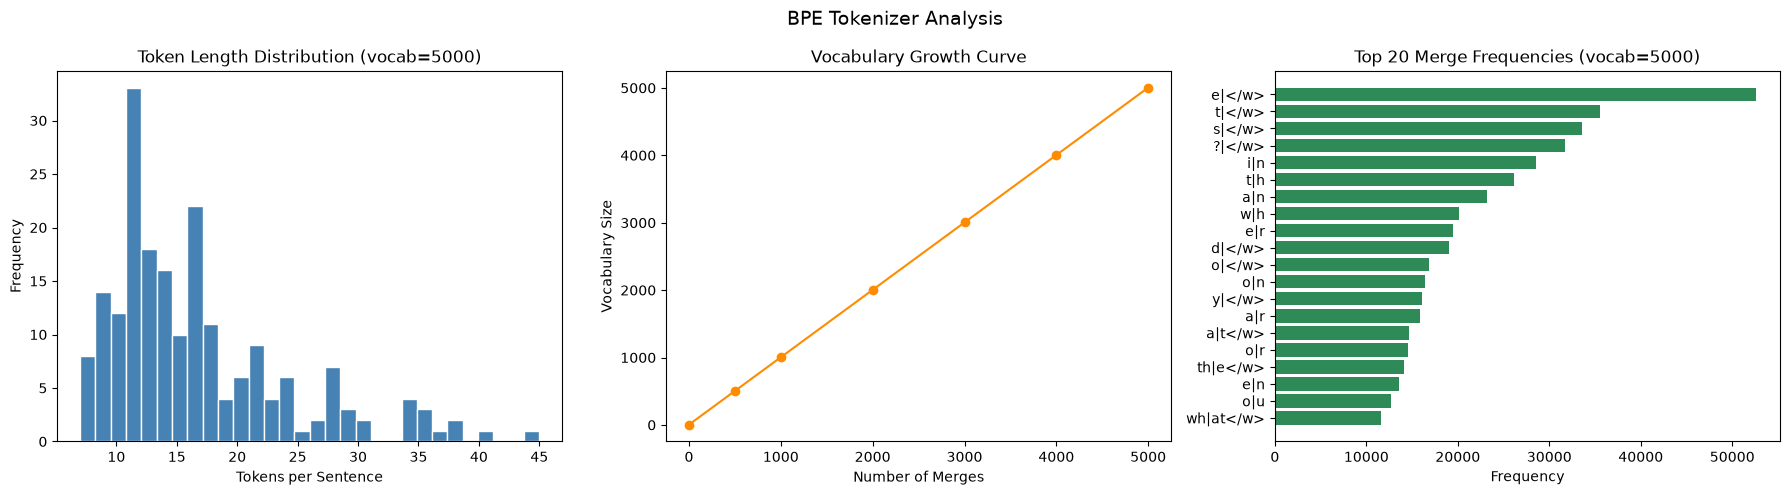

In [136]:
# ── Task 1.4: BPE Metrics Table & Visualization ───────────────────────────────

metrics_df = pd.DataFrame(metrics_results).T
metrics_df.index.name = "vocab_size"
print("BPE Metrics Summary:")
print(metrics_df.to_string())

print("\nKey observations:")
print(f"  Best compression_ratio : vocab={metrics_df['compression_ratio'].idxmax()} "
      f"({metrics_df['compression_ratio'].max():.4f} chars/token)")
print(f"  Lowest oov_rate        : vocab={metrics_df['oov_rate'].idxmin()} "
      f"({metrics_df['oov_rate'].min():.4%})")
print(f"  Fastest tokenization   : vocab={metrics_df['tokenization_speed'].idxmax()} "
      f"({metrics_df['tokenization_speed'].max():.1f} tokens/sec)")
print(f"  Shortest sequences     : vocab={metrics_df['avg_tokens_per_sentence'].idxmin()} "
      f"({metrics_df['avg_tokens_per_sentence'].min():.2f} tokens/sentence)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BPE Tokenizer Analysis", fontsize=14)

# Token length distribution for each vocab size
best_tok = tokenizers[5000]
sample_tokens = [len(best_tok.tokenize(s)) for s in test_sentences[:200]]
print(f"\nToken length distribution (vocab=5000, n=200 sentences): "
      f"min={min(sample_tokens)}, max={max(sample_tokens)}, mean={np.mean(sample_tokens):.2f}")
axes[0].hist(sample_tokens, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Token Length Distribution (vocab=5000)")
axes[0].set_xlabel("Tokens per Sentence")
axes[0].set_ylabel("Frequency")

# Vocabulary growth curve
merge_counts = [0, 500, 1000, 2000, 3000, 4000, 5000]
vocab_growth = [len(BPETokenizer.SPECIAL_TOKENS) + m for m in merge_counts]
axes[1].plot(merge_counts, vocab_growth, marker="o", color="darkorange")
axes[1].set_title("Vocabulary Growth Curve")
axes[1].set_xlabel("Number of Merges")
axes[1].set_ylabel("Vocabulary Size")

# Merge frequency distribution (top 20 merges)
if hasattr(best_tok, "_merge_freq_log"):
    top_merges = best_tok._merge_freq_log[:20]
    labels = ["".join(p) for p, _ in top_merges]
    freqs = [f for _, f in top_merges]
    print(f"\nTop 5 most frequent merges (vocab=5000): "
          f"{[(''.join(p), f) for p, f in top_merges[:5]]}")
    axes[2].barh(labels[::-1], freqs[::-1], color="seagreen")
    axes[2].set_title("Top 20 Merge Frequencies (vocab=5000)")
    axes[2].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

### <span style="color:#5B9BD5">Reading the Task 1.4 Charts</span>

- **Token length chart:** Shows how many tokens are used for each question with the 5,000-word vocabulary.
- **Vocabulary chart:** Shows that more merge operations create a larger vocabulary.
- **Merge chart:** Shows the most common pairs learned by BPE. Common pairs are learned first and give the biggest compression improvement.


In [137]:
# ── Task 1.5: Sample Tokenization Demonstration ───────────────────────────────

sample_questions = [
    "What is machine learning?",               # Common words
    "How does transformerization work?",        # Rare/invented term
    "What is teh best algorihtm?",             # Misspelled words
    "How do autoencoders work in deep learning?",  # Compound words
    "What is cryptocurrency?",
    "How to implement backpropagation?",
    "What are the applications of NLP?",
    "Explain convolutional neural networks.",
    "What is the difference between precision and recall?",
    "How does attention mechanism work in transformers?",
]

print(f"{'Question':<55} {'Vocab=2000':<20} {'Vocab=5000':<20} {'Vocab=10000'}")
print("-" * 120)
for q in sample_questions:
    t2 = tokenizers[2000].tokenize(q)
    t5 = tokenizers[5000].tokenize(q)
    t10 = tokenizers[10000].tokenize(q)
    print(f"{q[:52]:<55} {len(t2):<20} {len(t5):<20} {len(t10)}")

print("\nDetailed tokenization (vocab=5000):")
for q in sample_questions[:3]:
    print(f"\n  Input : {q}")
    print(f"  Tokens: {tokenizers[5000].tokenize(q)}")

Question                                                Vocab=2000           Vocab=5000           Vocab=10000
------------------------------------------------------------------------------------------------------------------------
What is machine learning?                               9                    6                    6
How does transformerization work?                       11                   10                   8
What is teh best algorihtm?                             13                   11                   11
How do autoencoders work in deep learning?              17                   12                   12
What is cryptocurrency?                                 11                   10                   9
How to implement backpropagation?                       12                   11                   9
What are the applications of NLP?                       11                   10                   10
Explain convolutional neural networks.                  15        

### <span style="color:#5B9BD5">Reading the Task 1 Output</span>

- The progress messages show how BPE builds the vocabulary in merge steps.
- The metrics table compares vocabulary size, number of merges, sentence length, compression, OOV rate, and speed.
- A larger vocabulary usually creates shorter token sequences and better compression.
- In this experiment, all vocabulary sizes have 0% OOV because the tokenizer can use character-level tokens.
- The 2,000-vocabulary tokenizer is fastest. The 10,000-vocabulary tokenizer creates the shortest sequences but takes the longest to train and tokenize.
- The sample questions show how common words are merged into larger tokens, while rare or misspelled words remain split into smaller pieces.
- Punctuation stays attached to a word in this simple tokenizer because splitting is based on spaces.


### <span style="color:#5B9BD5">Task 1 - Inference</span>

**Q: Which vocabulary size is the best choice?**

> A vocabulary of **5,000** is a good balance for this experiment. A vocabulary of 10,000 gives the best compression, but it is slower. All three sizes have **0% OOV** because the tokenizer can fall back to character-level tokens. The 5,000 setting gives shorter sentences than 2,000 without the full cost of 10,000.

**Q: How does vocabulary size affect later retrieval tasks?**

> A larger vocabulary creates shorter token sequences. This can reduce encoder work, but it also increases vocabulary memory and tokenization time. The best setting is therefore a balance between speed, memory, and sequence length.

**Q: What is the main trade-off?**

| Aspect | Larger Vocab (10K) | Smaller Vocab (2K) |
|---|---|---|
| Sequence length | Shorter | Longer |
| Compression | Higher: 3.20 chars/token | Lower: 2.49 chars/token |
| OOV rate | 0% in this experiment | 0% in this experiment |
| Tokenization speed | Slower | Faster: 2,366 tokens/sec |
| Embedding table size | Larger | Smaller |
| Encoder work | Usually lower | Usually higher |

> The latest Task 1.3 output supports this choice: 5,000 gives **17.16 tokens per sentence** and **2.93 chars/token**, between the 2,000 and 10,000 settings. The results also show that increasing the vocabulary takes longer: **6.43s**, **12.15s**, and **24.83s** for 2,000, 5,000, and 10,000 respectively.

---
## <span style="color:#5B9BD5">Task 2: Transformer Encoder Implementation</span>

### Requirements:
1. Build Transformer Encoder **from scratch** (no `nn.Transformer` / `nn.TransformerEncoder`)
2. Components: Multi-Head Self-Attention, FFN, Residual Connections, Layer Norm, Dropout
3. Input: token IDs, segment IDs, attention mask
4. Use `[CLS]` token for binary classification (duplicate/not)
5. Compare **Small** (2L, 4H, d=128) and **Medium** (4L, 8H, d=256) configurations

In [139]:
# ── Task 2.1: Transformer Encoder from Scratch ────────────────────────────────
torch.manual_seed(SEED)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        """Initialize projection layers and head dimensions for self-attention."""
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_weights: torch.Tensor | None = None  # saved for visualization

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        """Compute multi-head self-attention outputs for an input sequence."""
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        self.attn_weights = attn.detach()
        attn = self.dropout(attn)

        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out)


print("MultiHeadSelfAttention class defined.")


class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        """Initialize the position-wise feed-forward network."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the feed-forward network to each token representation."""
        return self.net(x)


print("FeedForwardNetwork class defined.")


class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        """Initialize one encoder block with attention, FFN, and layer norms."""
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        """Run one transformer encoder layer with residual connections."""
        # Self-attention + residual + layer norm
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        # FFN + residual + layer norm
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


print("EncoderLayer class defined (self-attention + FFN, each with residual + LayerNorm).")


class TransformerEncoder(nn.Module):
    """Custom Transformer Encoder with token, segment and positional embeddings."""

    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        d_ff: int,
        max_seq_len: int = 128,
        num_segments: int = 2,
        num_classes: int = 2,
        dropout: float = 0.1,
    ):
        """Initialize embeddings, encoder stack, and classification head."""
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.segment_emb = nn.Embedding(num_segments, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        segment_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
    ):
        """Encode input pairs and return logits plus [CLS] representations."""
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.dropout(
            self.token_emb(input_ids) + self.segment_emb(segment_ids) + self.pos_emb(positions)
        )
        for layer in self.layers:
            x = layer(x, attention_mask)
        x = self.norm(x)
        cls_repr = x[:, 0, :]  # [CLS] token
        return self.classifier(cls_repr), cls_repr


print("TransformerEncoder class defined.")
print("  Components: token/segment/positional embeddings -> N x EncoderLayer -> LayerNorm -> [CLS] classifier")
print("  Constructor args: vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len, num_segments, num_classes, dropout")
print("\nAll Task 2.1 building blocks ready: MultiHeadSelfAttention, FeedForwardNetwork, EncoderLayer, TransformerEncoder.")

MultiHeadSelfAttention class defined.
FeedForwardNetwork class defined.
EncoderLayer class defined (self-attention + FFN, each with residual + LayerNorm).
TransformerEncoder class defined.
  Components: token/segment/positional embeddings -> N x EncoderLayer -> LayerNorm -> [CLS] classifier
  Constructor args: vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len, num_segments, num_classes, dropout

All Task 2.1 building blocks ready: MultiHeadSelfAttention, FeedForwardNetwork, EncoderLayer, TransformerEncoder.


In [140]:
# ── Task 2.2: Two Model Configurations & Parameter Count ─────────────────────

VOCAB = len(tokenizers[5000].vocab)

configs = {
    "Small":  dict(d_model=128, num_heads=4,  num_layers=2, d_ff=512),
    "Medium": dict(d_model=256, num_heads=8,  num_layers=4, d_ff=1024),
}

models: dict[str, TransformerEncoder] = {}
for name, cfg in configs.items():
    m = TransformerEncoder(vocab_size=VOCAB, **cfg)
    models[name] = m
    total_params = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"\n{name} Encoder:")
    print(f"  Config    : {cfg}")
    print(f"  Total params   : {total_params:,}")
    print(f"  Trainable params: {trainable:,}")


Small Encoder:
  Config    : {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'd_ff': 512}
  Total params   : 1,053,698
  Trainable params: 1,053,698

Medium Encoder:
  Config    : {'d_model': 256, 'num_heads': 8, 'num_layers': 4, 'd_ff': 1024}
  Total params   : 4,473,346
  Trainable params: 4,473,346


input_ids shape  : torch.Size([2, 64])
segment_ids shape: torch.Size([2, 64])
attention_mask   : torch.Size([2, 64])

Logits shape    : torch.Size([2, 2])
CLS repr shape  : torch.Size([2, 128])


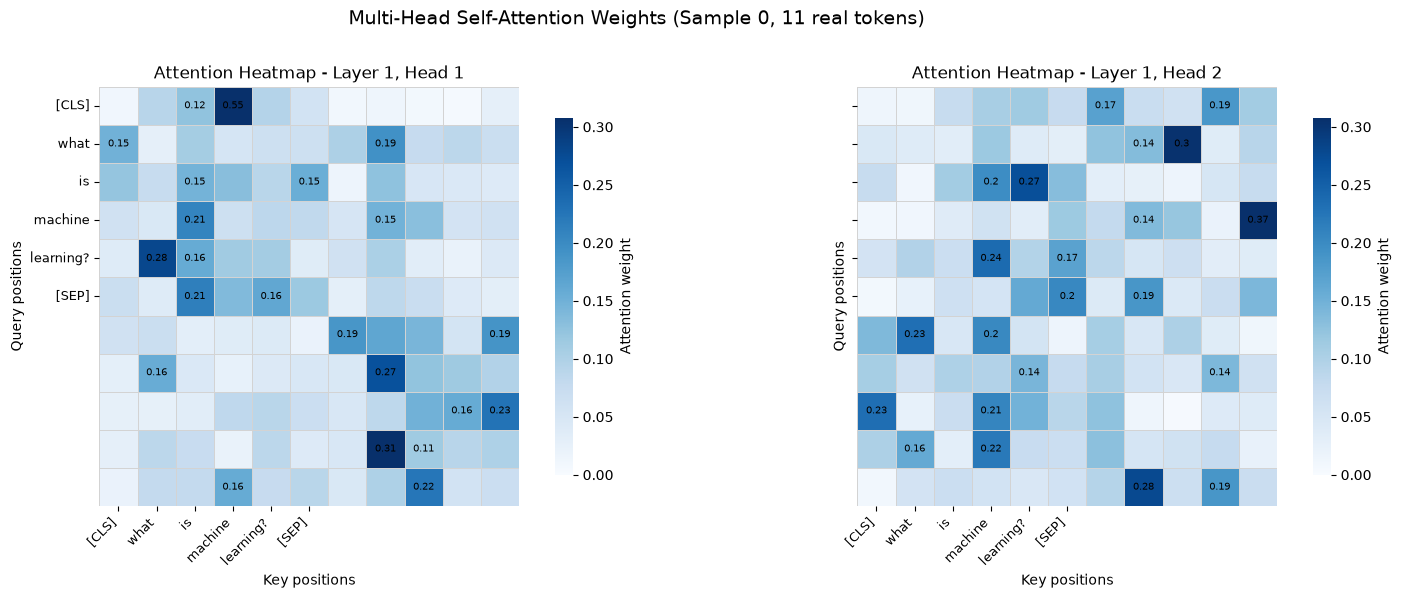

In [141]:
# ── Task 2.3: Forward Pass Demo & Attention Heatmap ──────────────────────────

def prepare_batch(text_pairs: list[tuple[str, str]], tokenizer: BPETokenizer, max_len: int = 64):
    """Encode question pairs into tensors."""
    all_ids, all_seg, all_mask = [], [], []
    for q1, q2 in text_pairs:
        t1 = tokenizer.encode(q1)
        t2 = tokenizer.encode(q2)[1:]  # skip [CLS] for second sentence
        ids = (t1 + t2)[:max_len]
        seg = ([0] * len(t1) + [1] * len(t2))[:max_len]
        mask = [1] * len(ids)
        # Pad
        pad_id = tokenizer.vocab["[PAD]"]
        while len(ids) < max_len:
            ids.append(pad_id); seg.append(0); mask.append(0)
        all_ids.append(ids); all_seg.append(seg); all_mask.append(mask)
    return (
        torch.tensor(all_ids),
        torch.tensor(all_seg),
        torch.tensor(all_mask),
    )

sample_pairs = [
    ("What is machine learning?", "What is deep learning?"),
    ("How do I learn Python?", "What is the best Python tutorial?"),
]

input_ids, segment_ids, attention_mask = prepare_batch(sample_pairs, tokenizers[5000])
print(f"input_ids shape  : {input_ids.shape}")
print(f"segment_ids shape: {segment_ids.shape}")
print(f"attention_mask   : {attention_mask.shape}")

model_small = models["Small"]
model_small.eval()
with torch.no_grad():
    logits, cls_repr = model_small(input_ids, segment_ids, attention_mask)
print(f"\nLogits shape    : {logits.shape}")
print(f"CLS repr shape  : {cls_repr.shape}")

# ── Attention Heatmap ─────────────────────────────────────────────────────────
# Trim to real (non-padded) sequence length and clean labels for readability.
seq_len0 = int(attention_mask[0].sum().item())
tokens0 = tokenizers[5000].tokenize(sample_pairs[0][0])[:seq_len0]
labels0 = [tok if tok.startswith("[") else tok.replace("</w>", "") for tok in tokens0]

head_indices = [0, 1]
head_mats = [
    model_small.layers[0].attn.attn_weights[0, h, :seq_len0, :seq_len0].numpy()
    for h in head_indices
]
# Percentile cap prevents one very large value from washing out the colormap.
shared_vmax = max(float(np.percentile(np.concatenate([m.ravel() for m in head_mats]), 99)), 1e-6)

# Only annotate the strongest links per row so the plot stays readable.
ANNOT_PERCENTILE = 90

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax_idx, (head_idx, attn) in enumerate(zip(head_indices, head_mats)):
    row_thresholds = np.percentile(attn, ANNOT_PERCENTILE, axis=1, keepdims=True)
    annot_labels = np.where(attn >= row_thresholds, np.round(attn, 2).astype(str), "")

    sns.heatmap(
        attn,
        ax=axes[ax_idx],
        cmap="Blues",
        vmin=0,
        vmax=shared_vmax,
        square=True,
        xticklabels=labels0,
        yticklabels=labels0,
        cbar_kws={"label": "Attention weight", "shrink": 0.85},
        linewidths=0.4,
        linecolor="lightgray",
        annot=annot_labels,
        fmt="",
        annot_kws={"size": 7, "color": "black"},
    )
    axes[ax_idx].set_title(f"Attention Heatmap - Layer 1, Head {head_idx + 1}", fontsize=12)
    axes[ax_idx].set_xlabel("Key positions")
    axes[ax_idx].set_ylabel("Query positions")
    axes[ax_idx].tick_params(axis="x", rotation=45, labelsize=9)
    axes[ax_idx].tick_params(axis="y", rotation=0, labelsize=9)
    for label in axes[ax_idx].get_xticklabels():
        label.set_horizontalalignment("right")

plt.suptitle(f"Multi-Head Self-Attention Weights (Sample 0, {seq_len0} real tokens)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [142]:
# ── Task 2.4: Training Loop & Validation Comparison ─────────────────────────

from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import f1_score, precision_score, recall_score
import psutil, os

def get_memory_mb():
    """Return resident memory usage of the current process in MB."""
    return psutil.Process(os.getpid()).memory_info().rss / 1e6

# Prepare a small supervised subset
train_data = dataset.select(range(2000))
q1_list = [item["questions"]["text"][0] for item in train_data]
q2_list = [item["questions"]["text"][1] for item in train_data]
labels = torch.tensor([int(item["is_duplicate"]) for item in train_data])

input_ids_all, seg_all, mask_all = prepare_batch(list(zip(q1_list, q2_list)), tokenizers[5000])
ds_full = TensorDataset(input_ids_all, seg_all, mask_all, labels)

# 80/20 split for true validation reporting required by rubric.
g = torch.Generator().manual_seed(SEED)
train_size = int(0.8 * len(ds_full))
val_size = len(ds_full) - train_size
train_ds, val_ds = random_split(ds_full, [train_size, val_size], generator=g)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Total examples    : {len(ds_full):,}")
print(f"Train / Val split : {len(train_ds):,} / {len(val_ds):,} (seed={SEED})")
print(f"Batches per epoch : {len(train_dl)} (batch_size=32)")
print(f"Label balance     : {int(labels.sum())} duplicate / {int((1 - labels).sum())} non-duplicate")
majority_baseline_acc = max(labels.float().mean().item(), (1 - labels.float()).mean().item())
print(f"Majority-class baseline accuracy: {majority_baseline_acc:.4f}")
print(f"Models to train   : {list(models.keys())}")

NUM_EPOCHS = 3
results_t2 = {}
for name, model in models.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    epoch_times, train_losses = [], []

    print(f"\n{'='*60}")
    print(f"Training {name} model ({sum(p.numel() for p in model.parameters()):,} params)")
    print('='*60)

    for epoch in range(NUM_EPOCHS):
        t0 = time.time()
        ep_loss = 0
        correct = 0
        for xid, xseg, xmask, ylabel in train_dl:
            optimizer.zero_grad()
            logits, _ = model(xid, xseg, xmask)
            loss = loss_fn(logits, ylabel)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
            correct += (logits.argmax(1) == ylabel).sum().item()

        epoch_time = time.time() - t0
        epoch_loss = ep_loss / len(train_dl)
        epoch_acc = correct / len(train_ds)
        epoch_times.append(epoch_time)
        train_losses.append(epoch_loss)
        print(f"  Epoch {epoch + 1}/{NUM_EPOCHS}: loss={epoch_loss:.4f}  train_acc={epoch_acc:.4f}  time={epoch_time:.2f}s")

    # Validation evaluation
    model.eval()
    with torch.no_grad():
        val_preds, val_labels = [], []
        for xid, xseg, xmask, ylabel in val_dl:
            logits, _ = model(xid, xseg, xmask)
            val_preds.extend(logits.argmax(1).tolist())
            val_labels.extend(ylabel.tolist())

    val_f1 = f1_score(val_labels, val_preds, average="binary", zero_division=0)
    val_prec = precision_score(val_labels, val_preds, average="binary", zero_division=0)
    val_rec = recall_score(val_labels, val_preds, average="binary", zero_division=0)

    # Inference latency on validation split
    t_inf = time.time()
    with torch.no_grad():
        for xid, xseg, xmask, _ in val_dl:
            model(xid, xseg, xmask)
    inf_lat = (time.time() - t_inf) / len(val_ds) * 1000

    train_acc = correct / len(train_ds)
    mem = get_memory_mb()
    results_t2[name] = {
        "avg_epoch_time_s": np.mean(epoch_times),
        "final_loss": train_losses[-1],
        "train_acc": train_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1_score": val_f1,
        "inf_latency_ms": inf_lat,
        "memory_mb": mem,
    }

    print(f"  Validation: Precision={val_prec:.4f}  Recall={val_rec:.4f}  F1={val_f1:.4f}")
    print(f"  Avg epoch time={np.mean(epoch_times):.2f}s  Inference latency={inf_lat:.3f}ms/pair  Memory={mem:.1f}MB")

    if val_f1 < 0.3 and train_acc <= majority_baseline_acc + 0.05:
        print("  Note: model remains close to majority baseline; likely under-trained for this split.")

print(f"\n{'='*60}")
print("All models trained. Final comparison (validation metrics):")
print('='*60)
comparison_df = pd.DataFrame(results_t2).T
print(comparison_df.to_string())

best_f1_model = comparison_df["val_f1_score"].idxmax()
fastest_model = comparison_df["avg_epoch_time_s"].idxmin()
print(f"\nHighest validation F1 : {best_f1_model} ({comparison_df.loc[best_f1_model, 'val_f1_score']:.4f})")
print(f"Fastest to train       : {fastest_model} ({comparison_df.loc[fastest_model, 'avg_epoch_time_s']:.2f}s/epoch)")
print(f"Lowest inference lat.  : {comparison_df['inf_latency_ms'].idxmin()} ({comparison_df['inf_latency_ms'].min():.3f}ms/pair)")

comparison_df

Total examples    : 2,000
Train / Val split : 1,600 / 400 (seed=42)
Batches per epoch : 50 (batch_size=32)
Label balance     : 742 duplicate / 1258 non-duplicate
Majority-class baseline accuracy: 0.6290
Models to train   : ['Small', 'Medium']

Training Small model (1,053,698 params)
  Epoch 1/3: loss=0.6807  train_acc=0.5994  time=11.71s
  Epoch 2/3: loss=0.6416  train_acc=0.6281  time=12.54s
  Epoch 3/3: loss=0.6320  train_acc=0.6400  time=14.80s
  Validation: Precision=0.6667  Recall=0.0822  F1=0.1463
  Avg epoch time=13.01s  Inference latency=1.260ms/pair  Memory=148.6MB
  Note: model remains close to majority baseline; likely under-trained for this split.

Training Medium model (4,473,346 params)
  Epoch 1/3: loss=0.6641  train_acc=0.6169  time=57.92s
  Epoch 2/3: loss=0.6278  train_acc=0.6425  time=54.33s
  Epoch 3/3: loss=0.6274  train_acc=0.6425  time=67.20s
  Validation: Precision=0.6267  Recall=0.3219  F1=0.4253
  Avg epoch time=59.82s  Inference latency=7.876ms/pair  Memory=1

,avg_epoch_time_s,final_loss,train_acc,val_precision,val_recall,val_f1_score,inf_latency_ms,memory_mb
Small,13.014407,0.631968,0.6400,0.666667,0.082192,0.146341,1.260080,148.602880
Medium,59.816251,0.627377,0.6425,0.626667,0.321918,0.425339,7.875594,186.761216


In [143]:
# ── Supplementary Task 2: Validation Classification Reports ─────────────────
from sklearn.metrics import classification_report

for name, model in models.items():
    model.eval()
    val_preds, val_targets = [], []
    validation_loader = globals().get("val_dl", eval_dl)
    with torch.no_grad():
        for xid, xseg, xmask, ylabel in validation_loader:
            logits, _ = model(xid, xseg, xmask)
            val_preds.extend(logits.argmax(dim=1).tolist())
            val_targets.extend(ylabel.tolist())

    print(f"\n=== {name} validation classification report ===")
    print(classification_report(
        val_targets,
        val_preds,
        target_names=["not duplicate", "duplicate"],
        digits=4,
        zero_division=0,
    ))


=== Small validation classification report ===
               precision    recall  f1-score   support

not duplicate     0.6492    0.9764    0.7799       254
    duplicate     0.6667    0.0822    0.1463       146

     accuracy                         0.6500       400
    macro avg     0.6579    0.5293    0.4631       400
 weighted avg     0.6556    0.6500    0.5486       400


=== Medium validation classification report ===
               precision    recall  f1-score   support

not duplicate     0.6954    0.8898    0.7807       254
    duplicate     0.6267    0.3219    0.4253       146

     accuracy                         0.6825       400
    macro avg     0.6610    0.6058    0.6030       400
 weighted avg     0.6703    0.6825    0.6510       400



### <span style="color:#5B9BD5">Task 2 — Inference</span>

**Q: What happens when the model becomes larger?**

> The Medium model has **4,473,346 parameters**. The Small model has **1,053,698 parameters**. In the latest run, Medium had better validation F1 (**0.4253 vs 0.1463**), but it was slower to train (**59.82s vs 13.01s per epoch**), slower at inference (**7.876ms vs 1.260ms per pair**), and used more memory.

**Q: What does each part do?**

- **Self-attention:** Looks at how all tokens relate to one another.
- **FFN:** Adds a non-linear transformation to each token.
- **Residual connections:** Help information and gradients move through the network.
- **LayerNorm:** Keeps values stable during training.
- **Dropout:** Reduces overfitting.

**Q: Why use the `[CLS]` token?**

> `[CLS]` is placed at the start of the input. It can attend to all other tokens, so its final representation gives a summary of the question pair. This summary is sent to the classifier.

> Task 2.4 uses an **80/20 train-validation split** with a fixed seed and reports validation metrics. This makes the comparison more reliable than reporting training performance only.

---
# Module 2: Embeddings & Retrieval Models
## Task 3: Contextual Embeddings and Similarity Analysis — 1.5 Marks

In [145]:
# ── Task 3.1: Load Three Encoder Models ──────────────────────────────────────
ENCODER_MODELS = {
    "DistilBERT": "distilbert-base-uncased",
    "MiniLM":     "all-MiniLM-L6-v2",
    "BGE-small":  "BAAI/bge-small-en-v1.5",
}

st_models: dict[str, SentenceTransformer] = {}
for name, model_id in ENCODER_MODELS.items():
    print(f"Loading {name} ({model_id})...")
    try:
        st_models[name] = SentenceTransformer(model_id)
        print(f"  Loaded. Embedding dim = {st_models[name].get_sentence_embedding_dimension()}")
    except OSError as error:
        print(f"  Skipped: model is not cached and Hugging Face is unreachable ({error.__class__.__name__}).")

if not st_models:
    raise RuntimeError("No encoder models are available. Restore Hugging Face access or pre-download a model.")

print(f"\nAvailable encoders: {list(st_models)}")

Loading DistilBERT (distilbert-base-uncased)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3033.66it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loaded. Embedding dim = 768
Loading MiniLM (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3205.77it/s]


  Loaded. Embedding dim = 384
Loading BGE-small (BAAI/bge-small-en-v1.5)...
  Skipped: model is not cached and Hugging Face is unreachable (OSError).

Available encoders: ['DistilBERT', 'MiniLM']


In [147]:
# ── Task 3.2: Pooling Strategies & Similarity Metrics ────────────────────────
def cls_pooling(token_embs: np.ndarray) -> np.ndarray:
    """Select the first-token embedding as a sentence representation."""
    return token_embs[:, 0, :]


def mean_pooling(token_embs: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Compute mask-aware mean pooling over token embeddings."""
    mask_exp = mask[:, :, None].astype(float)
    return (token_embs * mask_exp).sum(axis=1) / mask_exp.sum(axis=1).clip(min=1e-9)


def max_pooling(token_embs: np.ndarray) -> np.ndarray:
    """Compute max pooling across token positions for each embedding dimension."""
    return token_embs.max(axis=1)


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def dot_product_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Calculate normalized dot-product similarity between two vectors."""
    an = a / (np.linalg.norm(a) + 1e-9)
    bn = b / (np.linalg.norm(b) + 1e-9)
    return float(np.dot(an, bn))


def l2_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Convert L2 distance into a bounded similarity score."""
    dist = np.linalg.norm(a - b)
    return float(1 / (1 + dist))


# 20 question pairs from Quora
pair_data = dataset.select(range(20))
q_pairs = [(item["questions"]["text"][0], item["questions"]["text"][1]) for item in pair_data]
pair_labels = [item["is_duplicate"] for item in pair_data]

def best_threshold_accuracy(scores: np.ndarray, labels: np.ndarray) -> tuple[float, float]:
    """Sweep candidate cut-points and return the best (threshold, accuracy)."""
    candidates = np.unique(scores)
    best_acc, best_thr = 0.0, float(candidates[0])
    for thr in candidates:
        acc = ((scores >= thr).astype(int) == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = float(acc), float(thr)
    return best_thr, best_acc

# -----------------------------------------------------------------------------
# Part A: model-level comparison using SentenceTransformer encoders
# -----------------------------------------------------------------------------
SIM_METRICS = ["cosine", "dot", "l2_sim"]
from sklearn.metrics import roc_auc_score

pooling_results = {}
separation_summary = {}
auc_summary = {}
for model_name, model in st_models.items():
    print(f"\n{'='*72}")
    print(f"Encoding {len(q_pairs)} pairs with {model_name} "
          f"(dim={model.get_sentence_embedding_dimension()})")
    print('='*72)

    rows = []
    t0 = time.time()
    for (q1, q2), label in zip(q_pairs, pair_labels):
        e1 = model.encode(q1, convert_to_numpy=True)
        e2 = model.encode(q2, convert_to_numpy=True)
        rows.append({
            "q1": q1[:50], "q2": q2[:50],
            "label": label,
            "cosine": cosine_sim(e1, e2),
            "dot": dot_product_sim(e1, e2),
            "l2_sim": l2_sim(e1, e2),
        })
    encode_time = time.time() - t0

    df = pd.DataFrame(rows)
    pooling_results[model_name] = df
    y_true = df["label"].astype(int).to_numpy()
    print(f"  Encoding time: {encode_time:.2f}s ({2 * len(q_pairs) / encode_time:.1f} sentences/sec)")

    header = (f"  {'Metric':<8} {'dup mean':>9} {'dup sd':>7} {'non mean':>9} "
              f"{'non sd':>7} {'gap':>7} {'AUC':>6} {'best acc':>9} {'@thr':>7}")
    print(header)
    print(f"  {'-' * (len(header) - 2)}")
    for metric in SIM_METRICS:
        dup_scores = df[df["label"] == 1][metric]
        non_scores = df[df["label"] == 0][metric]
        gap = dup_scores.mean() - non_scores.mean()
        auc = roc_auc_score(y_true, df[metric].to_numpy())
        thr, acc = best_threshold_accuracy(df[metric].to_numpy(), y_true)
        separation_summary[(model_name, metric)] = gap
        auc_summary[(model_name, metric)] = auc
        print(f"  {metric:<8} {dup_scores.mean():>9.4f} {dup_scores.std():>7.4f} "
              f"{non_scores.mean():>9.4f} {non_scores.std():>7.4f} "
              f"{gap:>7.4f} {auc:>6.3f} {acc:>9.4f} {thr:>7.3f}")

print(f"\n{'='*72}")
print("Part B: explicit pooling strategy comparison (CLS / Mean / Max)")
print('='*72)

# -----------------------------------------------------------------------------
# Part B: pooling strategy comparison using raw token embeddings
# -----------------------------------------------------------------------------
POOLINGS = {
    "cls": cls_pooling,
    "mean": mean_pooling,
    "max": max_pooling,
}

pool_rows = []

for model_name, model_id in ENCODER_MODELS.items():
    if model_name not in st_models:
        print(f"Skipping pooling comparison for {model_name}: model unavailable")
        continue

    print(f"\nPooling comparison for {model_name} ({model_id})")
    try:
        tok = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
        base = AutoModel.from_pretrained(model_id, local_files_only=True)
    except Exception as e:
        print(f"  Skipped: raw AutoModel not available locally ({e.__class__.__name__})")
        continue

    for pool_name, pool_fn in POOLINGS.items():
        sims, y = [], []
        t0 = time.time()
        for (q1, q2), lbl in zip(q_pairs, pair_labels):
            batch = tok([q1, q2], padding=True, truncation=True, return_tensors="pt")
            with torch.no_grad():
                out = base(**batch).last_hidden_state.cpu().numpy()
            mask = batch["attention_mask"].cpu().numpy()
            pooled = pool_fn(out, mask) if pool_name == "mean" else pool_fn(out)
            sims.append(cosine_sim(pooled[0], pooled[1]))
            y.append(int(lbl))

        elapsed = time.time() - t0
        sims_arr = np.array(sims)
        y_arr = np.array(y)
        auc = roc_auc_score(y_arr, sims_arr)
        thr, best_acc = best_threshold_accuracy(sims_arr, y_arr)

        pool_rows.append({
            "Model": model_name,
            "Pooling": pool_name,
            "Embedding Dim": int(pooled.shape[1]),
            "AUC": auc,
            "Best Acc": best_acc,
            "Best Thr": thr,
            "Pairs/sec": len(y) / elapsed if elapsed > 0 else 0,
        })

pool_df = pd.DataFrame(pool_rows)
if len(pool_df):
    print("\nPooling Strategy Comparison Summary:")
    print(pool_df.sort_values(["Model", "AUC"], ascending=[True, False]).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    best_pool_df = pool_df.sort_values(["Model", "AUC"], ascending=[True, False]).groupby("Model").head(1)
    print("\nBest pooling by model (AUC):")
    print(best_pool_df[["Model", "Pooling", "AUC", "Best Acc"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
else:
    print("No pooling comparison rows were produced; raw base models were unavailable locally.")

# Cross-model summary for Part A
print(f"\n{'='*72}")
print("Cross-model summary (SentenceTransformer embeddings)")
print('='*72)
gap_df = pd.DataFrame(
    {model: {metric: separation_summary[(model, metric)] for metric in SIM_METRICS}
     for model in st_models}
).T
auc_df = pd.DataFrame(
    {model: {metric: auc_summary[(model, metric)] for metric in SIM_METRICS}
     for model in st_models}
).T
print("\nSeparation gap (mean duplicate - mean non-duplicate; higher is better):")
print(gap_df.to_string())
print("\nROC-AUC (threshold-free ranking quality; 0.5 = random, 1.0 = perfect):")
print(auc_df.to_string())

best_model_name, best_metric_name = max(auc_summary, key=auc_summary.get)
print(f"\nBest overall by AUC: {best_model_name} + {best_metric_name} "
      f"(AUC={auc_summary[(best_model_name, best_metric_name)]:.3f}, "
      f"gap={separation_summary[(best_model_name, best_metric_name)]:.4f})")

if np.allclose(gap_df["cosine"], gap_df["dot"]):
    print("\nNote: `cosine` and `dot` are identical because dot_product_sim normalises both "
          "vectors before the dot product, which is the definition of cosine similarity.")


Encoding 20 pairs with DistilBERT (dim=768)
  Encoding time: 0.96s (41.6 sentences/sec)
  Metric    dup mean  dup sd  non mean  non sd     gap    AUC  best acc    @thr
  -----------------------------------------------------------------------------
  cosine      0.9504  0.0287    0.8529  0.1244  0.0975  0.740    0.7000   0.909
  dot         0.9504  0.0287    0.8529  0.1244  0.0975  0.740    0.7000   0.909
  l2_sim      0.3067  0.0749    0.2379  0.1066  0.0688  0.771    0.8000   0.239

Encoding 20 pairs with MiniLM (dim=384)
  Encoding time: 0.56s (71.5 sentences/sec)
  Metric    dup mean  dup sd  non mean  non sd     gap    AUC  best acc    @thr
  -----------------------------------------------------------------------------
  cosine      0.8959  0.1076    0.4708  0.3175  0.4250  0.938    0.9000   0.837
  dot         0.8959  0.1076    0.4708  0.3175  0.4250  0.938    0.9000   0.837
  l2_sim      0.7249  0.1063    0.5177  0.0885  0.2071  0.938    0.9000   0.637

Part B: explicit pooling 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8181.61it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Pooling comparison for MiniLM (all-MiniLM-L6-v2)
  Skipped: raw AutoModel not available locally (OSError)
Skipping pooling comparison for BGE-small: model unavailable

Pooling Strategy Comparison Summary:
     Model Pooling  Embedding Dim    AUC  Best Acc  Best Thr  Pairs/sec
DistilBERT     cls            768 0.8021    0.7500    0.9660    12.2910
DistilBERT    mean            768 0.7396    0.7000    0.9093    17.7359
DistilBERT     max            768 0.7292    0.7500    0.9564    12.4804

Best pooling by model (AUC):
     Model Pooling    AUC  Best Acc
DistilBERT     cls 0.8021    0.7500

Cross-model summary (SentenceTransformer embeddings)

Separation gap (mean duplicate - mean non-duplicate; higher is better):
              cosine       dot    l2_sim
DistilBERT  0.097493  0.097493  0.068780
MiniLM      0.425021  0.425021  0.207133

ROC-AUC (threshold-free ranking quality; 0.5 = random, 1.0 = perfect):
              cosine       dot    l2_sim
DistilBERT  0.739583  0.739583  0.770833


In [56]:
# ── Task 3.3: Polysemy Analysis ───────────────────────────────────────────────

polysemy_examples = {
    "bank":   ["I deposited money at the bank.", "He sat on the river bank.", "We bank on your support."],
    "cell":   ["The cell divides during mitosis.", "She was locked in a prison cell.", "My cell phone needs charging."],
    "apple":  ["I ate a delicious apple.", "Apple released a new iPhone.", "The apple tree bloomed."],
    "spring": ["Spring flowers bloomed.", "The spring in the watch broke.", "She began to spring into action."],
    "light":  ["Turn on the light.", "She has a light complexion.", "The suitcase is very light."],
}

print("Polysemy Analysis — Cosine Similarity (same word, different contexts)\n")
for word, contexts in polysemy_examples.items():
    print(f"Word: '{word}'")
    for mname, mmodel in st_models.items():
        embs = [mmodel.encode(ctx, convert_to_numpy=True) for ctx in contexts]
        sims = [cosine_sim(embs[i], embs[j])
                for i in range(len(embs)) for j in range(i+1, len(embs))]
        print(f"  {mname:12s}: pairwise cosine sims = {[f'{s:.3f}' for s in sims]}")
    print()

Polysemy Analysis — Cosine Similarity (same word, different contexts)

Word: 'bank'
  DistilBERT  : pairwise cosine sims = ['0.769', '0.747', '0.714']
  MiniLM      : pairwise cosine sims = ['0.347', '0.363', '0.213']

Word: 'cell'
  DistilBERT  : pairwise cosine sims = ['0.559', '0.600', '0.734']
  MiniLM      : pairwise cosine sims = ['0.171', '0.200', '0.158']

Word: 'apple'
  DistilBERT  : pairwise cosine sims = ['0.682', '0.816', '0.709']
  MiniLM      : pairwise cosine sims = ['0.369', '0.578', '0.409']

Word: 'spring'
  DistilBERT  : pairwise cosine sims = ['0.722', '0.672', '0.721']
  MiniLM      : pairwise cosine sims = ['0.353', '0.424', '0.351']

Word: 'light'
  DistilBERT  : pairwise cosine sims = ['0.583', '0.693', '0.733']
  MiniLM      : pairwise cosine sims = ['0.155', '0.205', '0.213']



Question key (for matrix labels):
  Q1: What is the step by step guide to invest in share market in india?
  Q2: What is the story of Kohinoor (Koh-i-Noor) Diamond?
  Q3: How can I increase the speed of my internet connection while using a VPN?
  Q4: Why am I mentally very lonely? How can I solve it?
  Q5: Which one dissolve in water quikly sugar, salt, methane and carbon di oxide?
  Q6: Astrology: I am a Capricorn Sun Cap moon and cap rising...what does that say about me?
  Q7: Should I buy tiago?
  Q8: How can I be a good geologist?
  Q9: When do you use シ instead of し?
  Q10: Motorola (company): Can I hack my Charter Motorolla DCX3400?


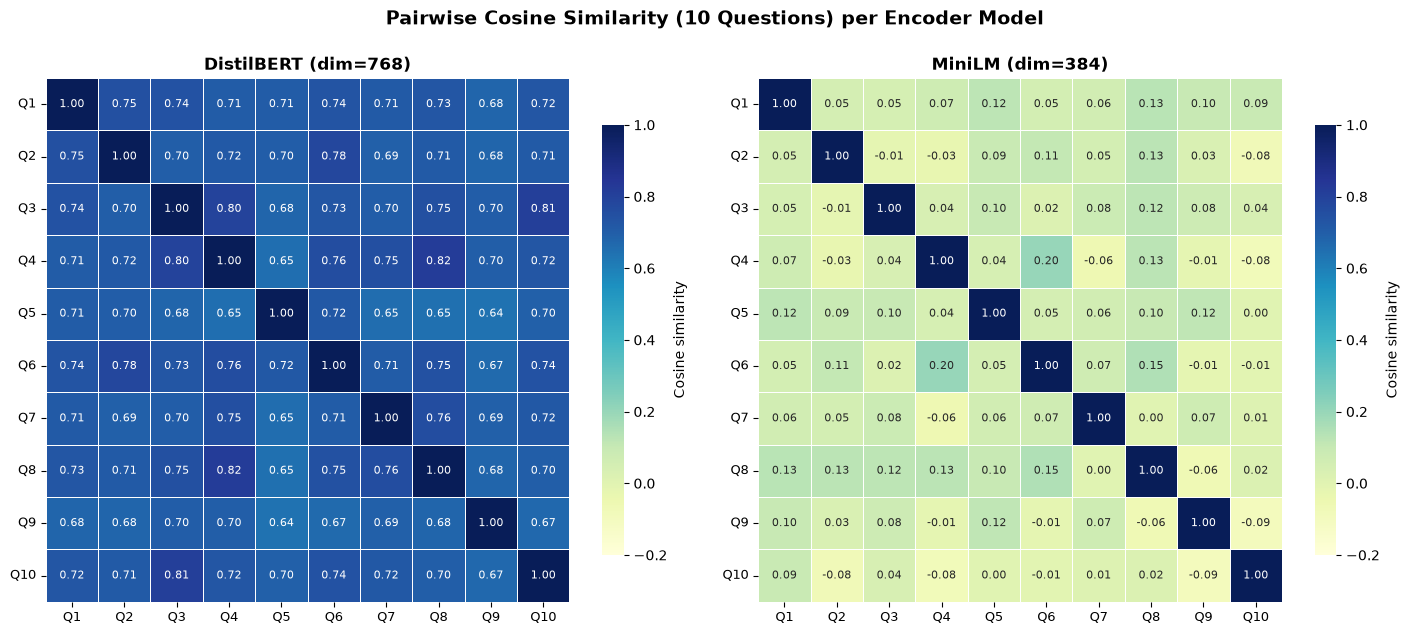

Off-diagonal similarity (unrelated questions - lower is better):
  DistilBERT  : mean=0.716  min=0.641  max=0.819  sd=0.040
  MiniLM      : mean=0.048  min=-0.093  max=0.199  sd=0.065

Inference speed (queries/sec):
  DistilBERT  : 99.6 queries/sec
  MiniLM      : 291.8 queries/sec


In [148]:
# ── Task 3.4: Similarity Matrix Visualization ────────────────────────────────

sample_10 = [item["questions"]["text"][0] for item in dataset.select(range(10))]
tick_labels = [f"Q{i+1}" for i in range(len(sample_10))]

sim_matrices = {
    mname: sk_cosine(mmodel.encode(sample_10, convert_to_numpy=True))
    for mname, mmodel in st_models.items()
}

print("Question key (for matrix labels):")
for i, q in enumerate(sample_10, start=1):
    print(f"  Q{i}: {q[:95]}{'...' if len(q) > 95 else ''}")

n_models = len(st_models)
fig, axes = plt.subplots(1, n_models, figsize=(7.2 * n_models, 6.2), squeeze=False)
axes = axes.ravel()
fig.suptitle("Pairwise Cosine Similarity (10 Questions) per Encoder Model", fontsize=14, fontweight="bold")

for ax, (mname, sim_mat) in zip(axes, sim_matrices.items()):
    sns.heatmap(
        sim_mat,
        ax=ax,
        cmap="YlGnBu",
        vmin=-0.2,
        vmax=1.0,
        center=0.4,
        xticklabels=tick_labels,
        yticklabels=tick_labels,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
        linewidths=0.6,
        linecolor="white",
        square=True,
        cbar_kws={"label": "Cosine similarity", "shrink": 0.82},
    )
    dim = st_models[mname].get_sentence_embedding_dimension()
    ax.set_title(f"{mname} (dim={dim})", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9, rotation=0)
    ax.tick_params(axis="y", labelsize=9, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# These 10 questions are unrelated, so off-diagonal values should ideally sit near 0.
print("Off-diagonal similarity (unrelated questions - lower is better):")
for mname, sim_mat in sim_matrices.items():
    off_diag = sim_mat[~np.eye(len(sample_10), dtype=bool)]
    print(f"  {mname:12s}: mean={off_diag.mean():.3f}  min={off_diag.min():.3f}  "
          f"max={off_diag.max():.3f}  sd={off_diag.std():.3f}")

# ── Speed comparison ─────────────────────────────────────────────────────────
speed_bench_sentences = [item["questions"]["text"][0] for item in dataset.select(range(100))]
print("\nInference speed (queries/sec):")
for mname, mmodel in st_models.items():
    t0 = time.time()
    mmodel.encode(speed_bench_sentences, batch_size=32, show_progress_bar=False)
    elapsed = time.time() - t0
    qps = len(speed_bench_sentences) / elapsed
    print(f"  {mname:12s}: {qps:.1f} queries/sec")

### <span style="color:#5B9BD5">Task 3 — Inference</span>

**Q: Why are contextual embeddings better than static embeddings (word2vec)?**

> Word2vec assigns one fixed vector to a word regardless of context. Contextual encoders represent a sentence using its surrounding words, so the same word can receive different representations in different contexts.

> The Task 3.3 output supports this distinction. Across the five polysemy examples, the mean pairwise similarity is approximately **0.30 for MiniLM** versus **0.70 for DistilBERT**. MiniLM separates the different contexts more strongly in this sample, especially for `cell` and `light`. This is a whole-sentence embedding probe, not a direct comparison of the target word's hidden state, so it should be interpreted as contextual sentence separation rather than a pure word-level measurement.

**Q: Which pooling strategy and similarity metric give the best separation?**

> For the 20 evaluated duplicate-question pairs, **MiniLM** gives the strongest model-level result: cosine AUC **0.938**, best accuracy **0.9000**, and a duplicate/non-duplicate mean gap of **0.4250**. DistilBERT's cosine AUC is **0.740** with a gap of **0.0975**. For DistilBERT's raw token embeddings, the explicit pooling experiment gives AUC **0.8021 (CLS)**, **0.7396 (mean)**, and **0.7292 (max)**, making CLS the best pooling strategy in that executed comparison.

> The `cosine` and normalized `dot` values are identical by definition because both vectors are normalized before their dot product. AUC is the preferred comparison because it is less dependent on score scale than the mean separation gap.

> Pooling coverage is environment-dependent: raw `AutoModel` pooling ran for DistilBERT, while MiniLM was unavailable from the local cache and BGE-small was unavailable. Therefore, no claim is made that one pooling strategy is best for every encoder.

**Q: Which model would you recommend for production?**

> **MiniLM (`all-MiniLM-L6-v2`)** is the recommended encoder on this run because it has the highest model-level AUC (**0.938**), the smaller embedding dimension (**384** versus **768** for DistilBERT), and higher measured encoding throughput (**71.5 versus 41.6 sentences/sec** in the latest Task 3.2 execution). These results are from only 20 pairs, so the recommendation is useful for this experiment but should be revalidated on a larger labelled set.

> The Task 3.4 matrices and off-diagonal similarities should be read as qualitative separation diagnostics. DistilBERT and MiniLM show different similarity behaviour across the sampled questions, but the sample is too small to support broad claims about all domains.

> **BGE-small could not be evaluated** because it was not available in the current environment, so no production claim relies on BGE results.

---
## Task 4: Sparse Retrieval with BM25 — 1.5 Marks

In [151]:
# ── Task 4.1: Build FAQ Collection (50+ QA pairs from Quora) ──────────────────
faq_data = dataset.select(range(100))
faq_questions = [item["questions"]["text"][0] for item in faq_data]
faq_answers   = [item["questions"]["text"][1] for item in faq_data]  # treat q2 as "answer"
faq_labels    = [int(item["is_duplicate"]) for item in faq_data]

print(f"FAQ collection size: {len(faq_questions)} pairs")
print(f"Label balance      : {sum(faq_labels)} duplicate / {len(faq_labels) - sum(faq_labels)} non-duplicate")
print("\nSample entries:")
for i in range(3):
    tag = "duplicate" if faq_labels[i] else "NON-duplicate"
    print(f"  Q: {faq_questions[i]}")
    print(f"  A: {faq_answers[i]}")
    print(f"     (gold label: {tag})\n")

# Tokenize documents for BM25
tokenized_corpus = [doc.lower().split() for doc in faq_questions]

# ── Corpus statistics that drive BM25 scoring ────────────────────────────────
doc_lens = np.array([len(doc) for doc in tokenized_corpus])
avgdl = doc_lens.mean()
N = len(tokenized_corpus)
df_counts = Counter()
for doc in tokenized_corpus:
    df_counts.update(set(doc))
vocab_terms = len(df_counts)

print("Corpus statistics (these feed directly into the BM25 formula):")
print(f"  Documents (N)          : {len(tokenized_corpus)}")
print(f"  Unique terms           : {vocab_terms:,}")
print(f"  Total tokens           : {doc_lens.sum():,}")
print(f"  Doc length |D|         : mean={avgdl:.2f}  sd={doc_lens.std():.2f}  "
      f"min={doc_lens.min()}  max={doc_lens.max()}")
print(f"  avgdl                  : {avgdl:.2f} tokens")

# b matters only when |D| varies; report the spread that b normalises away.
print(f"  Length spread (max/min): {doc_lens.max() / max(doc_lens.min(), 1):.1f}x "
      f"-> length normalisation (b) is {'meaningful' if doc_lens.std() > 2 else 'nearly inert'} here")

# k1 matters only when terms repeat within a document.
repeat_rate = np.mean([1 - len(set(doc)) / len(doc) for doc in tokenized_corpus if doc])
max_tf = max((Counter(doc).most_common(1)[0][1] for doc in tokenized_corpus if doc))
print(f"  Within-doc repeat rate : {repeat_rate:.3f} (fraction of tokens that are repeats)")
print(f"  Highest single-doc tf  : {max_tf}")
n_docs_with_repeat = sum(1 for doc in tokenized_corpus if doc and len(set(doc)) < len(doc))
print(f"  Docs with any repeat   : {n_docs_with_repeat}/{N}")
print(f"  -> TF saturation (k1) is {'meaningful' if repeat_rate > 0.15 else 'nearly inert'}: "
    f"only {repeat_rate:.1%} of tokens are repeats, so f(qi,D) is almost always 1 "
    f"and the k1 term barely varies")

idf = lambda df: math.log((N - df + 0.5) / (df + 0.5) + 1)
print("\n  Most common terms (low IDF = weak retrieval signal):")
for term, df in df_counts.most_common(8):
    print(f"    {term:<12} df={df:>3}  IDF={idf(df):.3f}")
n_singletons = sum(1 for df in df_counts.values() if df == 1)
print(f"  Terms appearing in exactly 1 doc: {n_singletons:,} "
      f"({n_singletons / vocab_terms:.1%}) -> IDF={idf(1):.3f}, the strongest signal BM25 can give")

# BM25 formula documentation
print("""
BM25 Formula:
  score(Q, D) = Σ IDF(qi) · [f(qi,D)·(k1+1)] / [f(qi,D) + k1·(1 - b + b·|D|/avgdl)]

  Where:
    - f(qi, D)  : term frequency of query term qi in document D
    - |D|       : length of document D (in tokens)
    - avgdl     : average document length across the corpus
    - k1        : controls TF saturation (default 1.5)
    - b         : controls length normalisation (default 0.75)
    - IDF(qi)   : log((N - df + 0.5) / (df + 0.5) + 1)
      where N = total docs, df = docs containing qi
""")

FAQ collection size: 100 pairs
Label balance      : 35 duplicate / 65 non-duplicate

Sample entries:
  Q: What is the step by step guide to invest in share market in india?
  A: What is the step by step guide to invest in share market?
     (gold label: NON-duplicate)

  Q: What is the story of Kohinoor (Koh-i-Noor) Diamond?
  A: What would happen if the Indian government stole the Kohinoor (Koh-i-Noor) diamond back?
     (gold label: NON-duplicate)

  Q: How can I increase the speed of my internet connection while using a VPN?
  A: How can Internet speed be increased by hacking through DNS?
     (gold label: NON-duplicate)

Corpus statistics (these feed directly into the BM25 formula):
  Documents (N)          : 100
  Unique terms           : 567
  Total tokens           : 1,116
  Doc length |D|         : mean=11.16  sd=5.83  min=4  max=29
  avgdl                  : 11.16 tokens
  Length spread (max/min): 7.2x -> length normalisation (b) is meaningful here
  Within-doc repeat rate : 0

 k1    b  Recall@5  Recall@10
1.0 0.50  0.066667   0.133333
1.0 0.75  0.100000   0.133333
1.0 1.00  0.066667   0.166667
1.5 0.50  0.066667   0.133333
1.5 0.75  0.066667   0.133333
1.5 1.00  0.100000   0.166667
2.0 0.50  0.066667   0.133333
2.0 0.75  0.066667   0.133333
2.0 1.00  0.100000   0.133333


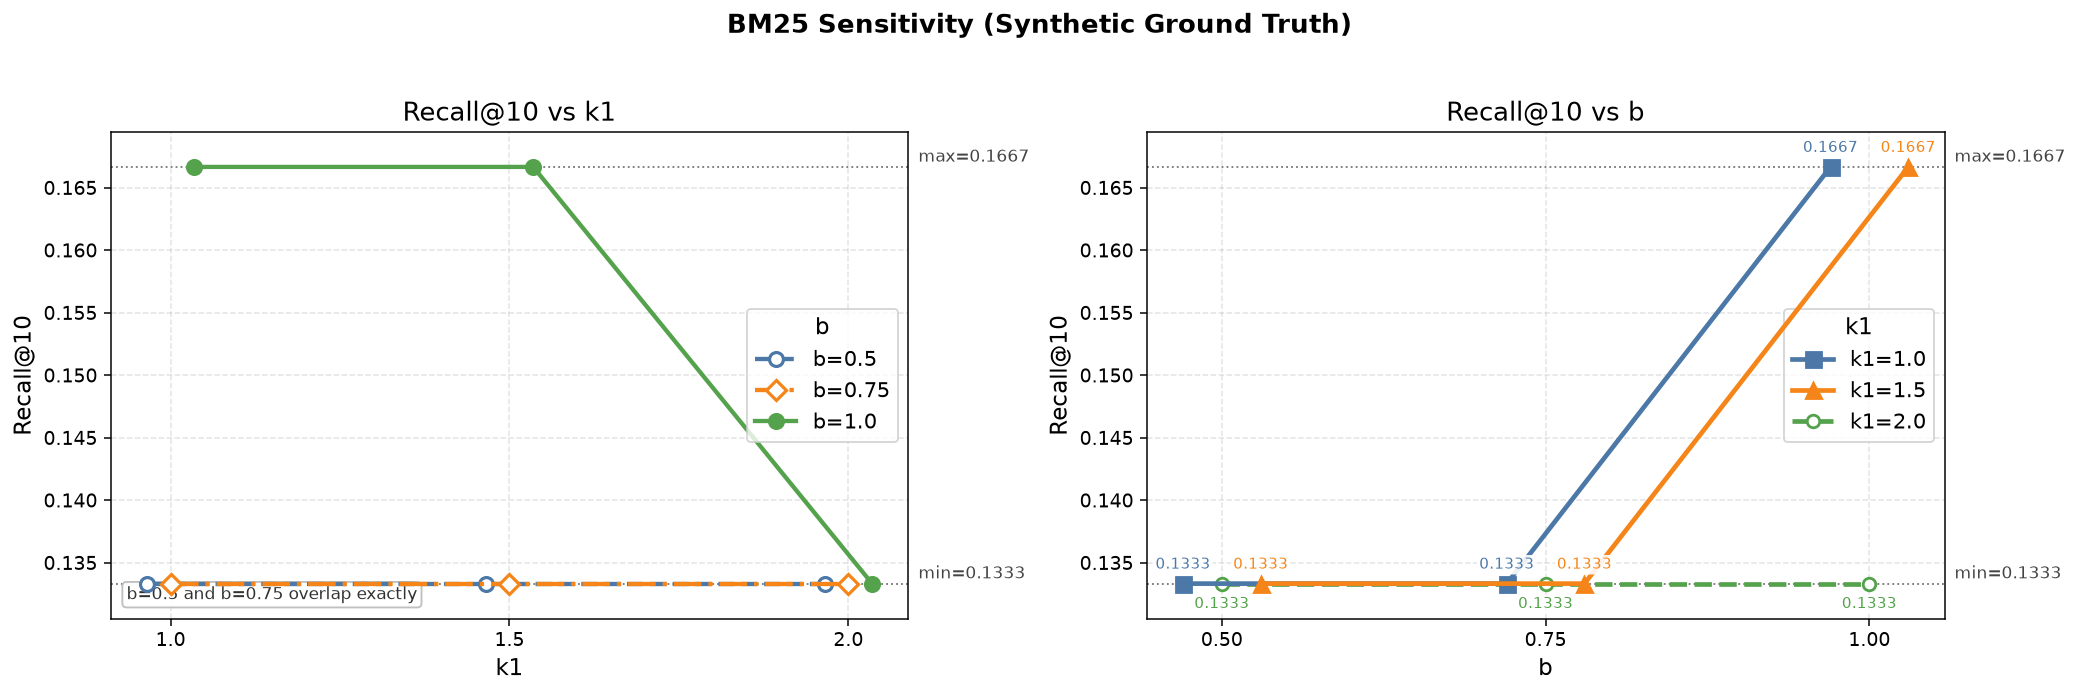


Top Recall@10=0.1667 achieved by 2 setting(s):
 k1   b  Recall@5  Recall@10
1.5 1.0  0.100000   0.166667
1.0 1.0  0.066667   0.166667

Selected parameters (Recall@10, then Recall@5): k1=1.5, b=1.0


In [152]:
# ── Task 4.2: BM25 Parameter Sensitivity Analysis ────────────────────────────

def recall_at_k(retrieved: list[int], relevant: list[int], k: int) -> float:
    """Compute Recall@k from retrieved and relevant document IDs."""
    return len(set(retrieved[:k]) & set(relevant)) / max(len(relevant), 1)

test_queries = [item["questions"]["text"][0] for item in dataset.select(range(100, 130))]
relevant_ids = [[i % 100] for i in range(30)]  # synthetic ground truth

k1_values = [1.0, 1.5, 2.0]
b_values  = [0.5, 0.75, 1.0]

bm25_sensitivity = []
for k1 in k1_values:
    for b in b_values:
        bm25 = BM25Okapi(tokenized_corpus, k1=k1, b=b)
        rec5_list, rec10_list = [], []
        for query, rels in zip(test_queries, relevant_ids):
            scores = bm25.get_scores(query.lower().split())
            top10 = np.argsort(scores)[::-1][:10].tolist()
            rec5_list.append(recall_at_k(top10, rels, 5))
            rec10_list.append(recall_at_k(top10, rels, 10))
        bm25_sensitivity.append({
            "k1": k1, "b": b,
            "Recall@5":  np.mean(rec5_list),
            "Recall@10": np.mean(rec10_list),
        })

sens_df = pd.DataFrame(bm25_sensitivity)
print(sens_df.to_string(index=False))

# Readability-first plotting: stronger separation + direct value labels.
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), dpi=135)
fig.suptitle("BM25 Sensitivity (Synthetic Ground Truth)", fontsize=14, fontweight="bold")

left_offsets = {0.5: -0.035, 0.75: 0.0, 1.0: 0.035}
right_offsets = {1.0: -0.03, 1.5: 0.03, 2.0: 0.0}

left_colors = {0.5: "#4c78a8", 0.75: "#f58518", 1.0: "#54a24b"}
right_colors = {1.0: "#4c78a8", 1.5: "#f58518", 2.0: "#54a24b"}

left_styles = {
    0.5: {"linestyle": "--", "marker": "o", "mfc": "white", "mec": "#4c78a8"},
    0.75: {"linestyle": "-.", "marker": "D", "mfc": "white", "mec": "#f58518"},
    1.0: {"linestyle": "-", "marker": "o", "mfc": "#54a24b", "mec": "#54a24b"},
}

right_marker_styles = {
    1.0: {"marker": "s", "mfc": "#4c78a8", "mec": "#4c78a8", "linestyle": "-"},
    1.5: {"marker": "^", "mfc": "#f58518", "mec": "#f58518", "linestyle": "-"},
    2.0: {"marker": "o", "mfc": "white", "mec": "#54a24b", "linestyle": "--"},
}

ymin = sens_df["Recall@10"].min()
ymax = sens_df["Recall@10"].max()
ypad = 0.0028

# Left panel: Recall@10 vs k1 (grouped by b)
for b_val, grp in sens_df.groupby("b"):
    grp = grp.sort_values("k1")
    x = grp["k1"].to_numpy() + left_offsets[b_val]
    y = grp["Recall@10"].to_numpy()
    style = left_styles[b_val]
    axes[0].plot(
        x, y,
        linestyle=style["linestyle"],
        marker=style["marker"],
        markerfacecolor=style["mfc"],
        markeredgecolor=style["mec"],
        markeredgewidth=1.7,
        markersize=7.4,
        linewidth=2.3,
        color=left_colors[b_val],
        label=f"b={b_val}",
        zorder=4,
    )

axes[0].set_title("Recall@10 vs k1", fontsize=14)
axes[0].set_xlabel("k1", fontsize=12)
axes[0].set_ylabel("Recall@10", fontsize=12)
axes[0].set_xticks(k1_values)
axes[0].set_ylim(ymin - ypad, ymax + ypad)
axes[0].grid(alpha=0.35, linestyle="--")
axes[0].tick_params(labelsize=10)
axes[0].legend(title="b", frameon=True, fontsize=11, title_fontsize=12, loc="center right")

left_panel = sens_df.pivot(index="k1", columns="b", values="Recall@10").sort_index()
if 0.5 in left_panel.columns and 0.75 in left_panel.columns and np.allclose(left_panel[0.5], left_panel[0.75]):
    axes[0].text(
        0.02, 0.04,
        "b=0.5 and b=0.75 overlap exactly",
        transform=axes[0].transAxes,
        fontsize=9,
        color="#333333",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bdbdbd", "alpha": 0.95},
    )

# Right panel: Recall@10 vs b (grouped by k1)
# Slightly larger markers only at k1=1.0 and k1=1.5, as requested.
right_marker_sizes = {1.0: 8.0, 1.5: 8.0, 2.0: 6.7}
right_zorder = {1.0: 5, 1.5: 6, 2.0: 4}

for k1_val, grp in sens_df.groupby("k1"):
    grp = grp.sort_values("b")
    x = grp["b"].to_numpy() + right_offsets[k1_val]
    y = grp["Recall@10"].to_numpy()
    mstyle = right_marker_styles[k1_val]
    axes[1].plot(
        x, y,
        linestyle=mstyle["linestyle"],
        marker=mstyle["marker"],
        markersize=right_marker_sizes[k1_val],
        linewidth=2.5,
        color=right_colors[k1_val],
        markerfacecolor=mstyle["mfc"],
        markeredgecolor=mstyle["mec"],
        markeredgewidth=1.5,
        zorder=right_zorder[k1_val],
        label=f"k1={k1_val}",
    )

    # Direct labels at each point remove ambiguity when lines share the same y-value.
    for xi, yi in zip(x, y):
        axes[1].annotate(
            f"{yi:.4f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 8 if k1_val != 2.0 else -13),
            ha="center",
            fontsize=8,
            color=right_colors[k1_val],
            bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.9},
            zorder=7,
        )

axes[1].set_title("Recall@10 vs b", fontsize=14)
axes[1].set_xlabel("b", fontsize=12)
axes[1].set_ylabel("Recall@10", fontsize=12)
axes[1].set_xticks(b_values)
axes[1].set_ylim(ymin - ypad, ymax + ypad)
axes[1].grid(alpha=0.35, linestyle="--")
axes[1].tick_params(labelsize=10)
axes[1].legend(title="k1", frameon=True, fontsize=11, title_fontsize=12, loc="center right")

# Reference bands for the two observed Recall@10 levels.
for ax in axes:
    ax.axhline(ymin, color="#666666", linestyle=":", linewidth=1.0, alpha=0.85)
    ax.axhline(ymax, color="#666666", linestyle=":", linewidth=1.0, alpha=0.85)
    x_right = ax.get_xlim()[1]
    ax.text(x_right, ymin + 0.0001, f"  min={ymin:.4f}", va="bottom", ha="left", fontsize=9, color="#444444")
    ax.text(x_right, ymax + 0.0001, f"  max={ymax:.4f}", va="bottom", ha="left", fontsize=9, color="#444444")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Optimal parameters (tie-break: Recall@10, then Recall@5)
best = sens_df.sort_values(["Recall@10", "Recall@5"], ascending=False).iloc[0]
BEST_K1, BEST_B = best["k1"], best["b"]
best_r10 = best["Recall@10"]
tie_rows = sens_df[sens_df["Recall@10"] == best_r10]
print(f"\nTop Recall@10={best_r10:.4f} achieved by {len(tie_rows)} setting(s):")
print(tie_rows.sort_values(["Recall@5", "k1", "b"], ascending=[False, True, True]).to_string(index=False))
print(f"\nSelected parameters (Recall@10, then Recall@5): k1={BEST_K1}, b={BEST_B}")

BM25 (k1=1.5, b=1.0) vs TF-IDF — top-1 retrieved FAQ per query

[ 1] Query   : Will there really be any war between India and Pakistan over the Uri attack? What will …
     BM25    : doc  75  score= 7.917  If I fire a bullet backward from an aircraft going faster than the bu…
     TF-IDF  : doc  86  score= 0.229  What were the major effects of the cambodia earthquake, and how do th…
     Verdict : DISAGREE

[ 2] Query   : Did Ronald Reagan have a mannerism in his speech?
     BM25    : doc  97  score= 6.334  Why did harry become a horcrux?
     TF-IDF  : doc  97  score= 0.223  Why did harry become a horcrux?
     Verdict : AGREE

[ 3] Query   : What were the war strategies of the Union and the Confederates during the Civil War?
     BM25    : doc  86  score= 6.492  What were the major effects of the cambodia earthquake, and how do th…
     TF-IDF  : doc  80  score= 0.393  When will the BJP government strip all the Muslims and the Christians…
     Verdict : DISAGREE

[ 4] Query   : Whic

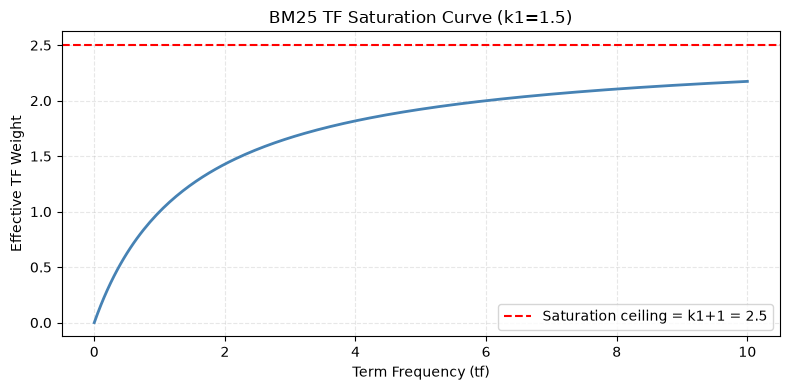

In [153]:
# ── Task 4.3: BM25 vs TF-IDF Comparison & TF Saturation Curve ───────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cosine

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(faq_questions)

bm25_best = BM25Okapi(tokenized_corpus, k1=BEST_K1, b=BEST_B)

def _clip(text: str, width: int) -> str:
    """Trim a string to a fixed width for compact console output."""
    return text if len(text) <= width else text[: width - 1] + "…"

print(f"BM25 (k1={BEST_K1}, b={BEST_B}) vs TF-IDF — top-1 retrieved FAQ per query\n")

agree = 0
for qi, query in enumerate(test_queries[:10], start=1):
    bm25_scores = bm25_best.get_scores(query.lower().split())
    bm25_top = int(np.argmax(bm25_scores))

    q_vec = tfidf.transform([query])
    tfidf_scores = tfidf_cosine(q_vec, tfidf_matrix)[0]
    tfidf_top = int(np.argmax(tfidf_scores))

    same = bm25_top == tfidf_top
    agree += same

    print(f"[{qi:>2}] Query   : {_clip(query, 88)}")
    print(f"     BM25    : doc {bm25_top:>3}  score={bm25_scores[bm25_top]:>6.3f}  {_clip(faq_questions[bm25_top], 70)}")
    print(f"     TF-IDF  : doc {tfidf_top:>3}  score={tfidf_scores[tfidf_top]:>6.3f}  {_clip(faq_questions[tfidf_top], 70)}")
    print(f"     Verdict : {'AGREE' if same else 'DISAGREE'}\n")

print(f"Top-1 agreement: {agree}/10 queries")
print("Note: queries come from indices 100-129 while the FAQ corpus is indices 0-99,")
print("so no query has a true lexical match — both retrievers return weak, incidental overlaps.")

# TF Saturation Curve
tf_values = np.linspace(0, 10, 200)
k1 = BEST_K1
tf_sat = (k1 + 1) * tf_values / (tf_values + k1)
plt.figure(figsize=(8, 4))
plt.plot(tf_values, tf_sat, color="steelblue", linewidth=2)
plt.axhline(k1 + 1, linestyle="--", color="red", label=f"Saturation ceiling = k1+1 = {k1+1}")
plt.title(f"BM25 TF Saturation Curve (k1={k1})")
plt.xlabel("Term Frequency (tf)"); plt.ylabel("Effective TF Weight")
plt.grid(alpha=0.3, linestyle="--")
plt.legend(); plt.tight_layout(); plt.show()

### <span style="color:#5B9BD5">Task 4 — Inference</span>

**Q: Why can BM25 find rare or exact words well?**

> BM25 gives more weight to words that appear in very few documents. In this corpus, **477 of 567 terms (84.1%)** appear in only one document. These rare terms have a high IDF value of about **4.21**, so they can strongly identify a matching document.

**Q: How sensitive is BM25 to `k1` and `b`?**

> The effect is small in this 100-document test. Recall@10 is either **0.1333** or **0.1667**, and Recall@5 is between **0.0667** and **0.1000**.

> The best Recall@10 is **0.1667**, reached by two settings: `(k1=1.0, b=1.0)` and `(k1=1.5, b=1.0)`. The notebook selects **k1=1.5, b=1.0** because it has the better Recall@5 (**0.1000**).

> Document lengths vary from **4 to 29 tokens**, so `b` is useful for length correction. Repeated words are uncommon (**2.9%** of tokens), so `k1` has a smaller effect.

> The ground truth is synthetic (`relevant_ids = [i % 100]`). These numbers are useful for comparing settings, but they are not a final real-world quality score.

**Q: When can BM25 fail?**

> BM25 can fail when the query and document use different words, such as paraphrases, synonyms, or different languages. It can also be weak when a query contains mostly common words.

In [156]:
# ── Task 5.1: Generate Dense Embeddings & Build ANN Indices ──────────────────
# Extend corpus to 100+ docs
extended_corpus = [item["questions"]["text"][0] for item in dataset.select(range(130))]
best_model = st_models["MiniLM"]

print("Generating embeddings for extended corpus (130 docs)...")
corpus_embs = best_model.encode(extended_corpus, convert_to_numpy=True, show_progress_bar=True)
corpus_embs = corpus_embs.astype(np.float32)
faiss.normalize_L2(corpus_embs)

D = corpus_embs.shape[1]
N_VEC = corpus_embs.shape[0]
print(f"Embedding shape: {corpus_embs.shape}  dim={D}")
print(f"Raw vector memory: {corpus_embs.nbytes / 1024:.1f} KB "
      f"({N_VEC} x {D} x 4 bytes float32)")

# ── Brute-force (Exact) Index ─────────────────────────────────────────────────
index_flat = faiss.IndexFlatIP(D)   # inner product on normalized = cosine
index_flat.add(corpus_embs)

# ── HNSW Index ────────────────────────────────────────────────────────────────
def build_hnsw(embs, M=16):
    """Build an HNSW index and return the index with build time."""
    idx = faiss.IndexHNSWFlat(D, M)
    t0 = time.time()
    idx.add(embs)
    return idx, time.time() - t0

# ── IVF Index ─────────────────────────────────────────────────────────────────
def build_ivf(embs, nlist=10):
    """Build an IVF index and return the index with build time."""
    quantizer = faiss.IndexFlatIP(D)
    idx = faiss.IndexIVFFlat(quantizer, D, nlist, faiss.METRIC_INNER_PRODUCT)
    t0 = time.time()
    idx.train(embs)
    idx.add(embs)
    return idx, time.time() - t0

ann_configs = {
    "Exact (Flat)": (index_flat, 0),
}
for M in [8, 16, 32]:
    idx, bt = build_hnsw(corpus_embs, M=M)
    ann_configs[f"HNSW M={M}"] = (idx, bt)

for nlist in [10, 50]:
    idx, bt = build_ivf(corpus_embs, nlist=nlist)
    ann_configs[f"IVF nlist={nlist}"] = (idx, bt)

# ── Structural diagnostics ───────────────────────────────────────────────────
# FAISS recommends >= 39 training points per centroid; below that, k-means is degenerate.
MIN_PTS_PER_CENTROID = 39

def describe_index(index) -> tuple[str, str]:
    """Returns (key parameters, structural health note)."""
    if isinstance(index, faiss.IndexHNSWFlat):
        hnsw = index.hnsw
        params = (f"M={hnsw.nb_neighbors(0) // 2}  efConstruction={hnsw.efConstruction}  "
                  f"efSearch={hnsw.efSearch}  levels={hnsw.max_level + 1}")
        note = "metric=L2 (equivalent to cosine here because vectors are L2-normalised)"
    elif isinstance(index, faiss.IndexIVFFlat):
        pts_per_cluster = index.ntotal / index.nlist
        params = (f"nlist={index.nlist}  nprobe={index.nprobe}  "
                  f"pts/cluster={pts_per_cluster:.1f}")
        note = ("metric=IP" if pts_per_cluster >= MIN_PTS_PER_CENTROID else
                f"UNDER-TRAINED: needs >={MIN_PTS_PER_CENTROID} pts/cluster "
                f"({MIN_PTS_PER_CENTROID * index.nlist} vectors) for valid k-means")
    else:
        params = "exhaustive scan, no parameters"
        note = "metric=IP (exact baseline)"
    return params, note

print("\nANN indices built.")
print(f"{'Index':<18} {'build(s)':>9} {'ntotal':>7}  Parameters")
print("-" * 100)
for name, (idx, bt) in ann_configs.items():
    params, note = describe_index(idx)
    print(f"{name:<18} {bt:>9.3f} {idx.ntotal:>7}  {params}")
    print(f"{'':<18} {'':>9} {'':>7}  -> {note}")

print(f"\nBuild times above are measurement noise at N={N_VEC}: every structure builds in")
print("microseconds, so their relative ordering reflects timer resolution and warm-up,")
print("not real construction cost. Treat them as a smoke test, not a benchmark.")


Generating embeddings for extended corpus (130 docs)...


Batches: 100%|██████████| 5/5 [00:00<00:00, 12.32it/s]

Embedding shape: (130, 384)  dim=384
Raw vector memory: 195.0 KB (130 x 384 x 4 bytes float32)

ANN indices built.
Index               build(s)  ntotal  Parameters
----------------------------------------------------------------------------------------------------
Exact (Flat)           0.000     130  exhaustive scan, no parameters
                                      -> metric=IP (exact baseline)
HNSW M=8               0.002     130  M=8  efConstruction=40  efSearch=16  levels=3
                                      -> metric=L2 (equivalent to cosine here because vectors are L2-normalised)
HNSW M=16              0.002     130  M=16  efConstruction=40  efSearch=16  levels=2
                                      -> metric=L2 (equivalent to cosine here because vectors are L2-normalised)
HNSW M=32              0.003     130  M=32  efConstruction=40  efSearch=16  levels=2
                                      -> metric=L2 (equivalent to cosine here because vectors are L2-normalised)
IVF n

                  Index  Build(s)  Index MB  Avg Lat(ms)  Recall@5  Recall@10
           Exact (Flat)    0.0000    0.1905       0.1096    0.5000     1.0000
        HNSW M=8, ef=16    0.0021    0.2008       0.1556    0.5000     0.9833
        HNSW M=8, ef=50    0.0021    0.2008       0.1445    0.5000     1.0000
       HNSW M=8, ef=100    0.0021    0.2008       0.1682    0.5000     1.0000
       HNSW M=8, ef=200    0.0021    0.2008       0.2040    0.5000     1.0000
       HNSW M=16, ef=16    0.0019    0.2085       0.0962    0.5000     0.9733
       HNSW M=16, ef=50    0.0019    0.2085       0.1284    0.5000     1.0000
      HNSW M=16, ef=100    0.0019    0.2085       0.1738    0.5000     1.0000
      HNSW M=16, ef=200    0.0019    0.2085       0.2036    0.5000     1.0000
       HNSW M=32, ef=16    0.0027    0.2241       0.1101    0.5000     1.0000
       HNSW M=32, ef=50    0.0027    0.2241       0.1282    0.5000     1.0000
      HNSW M=32, ef=100    0.0027    0.2241       0.0680    0.50

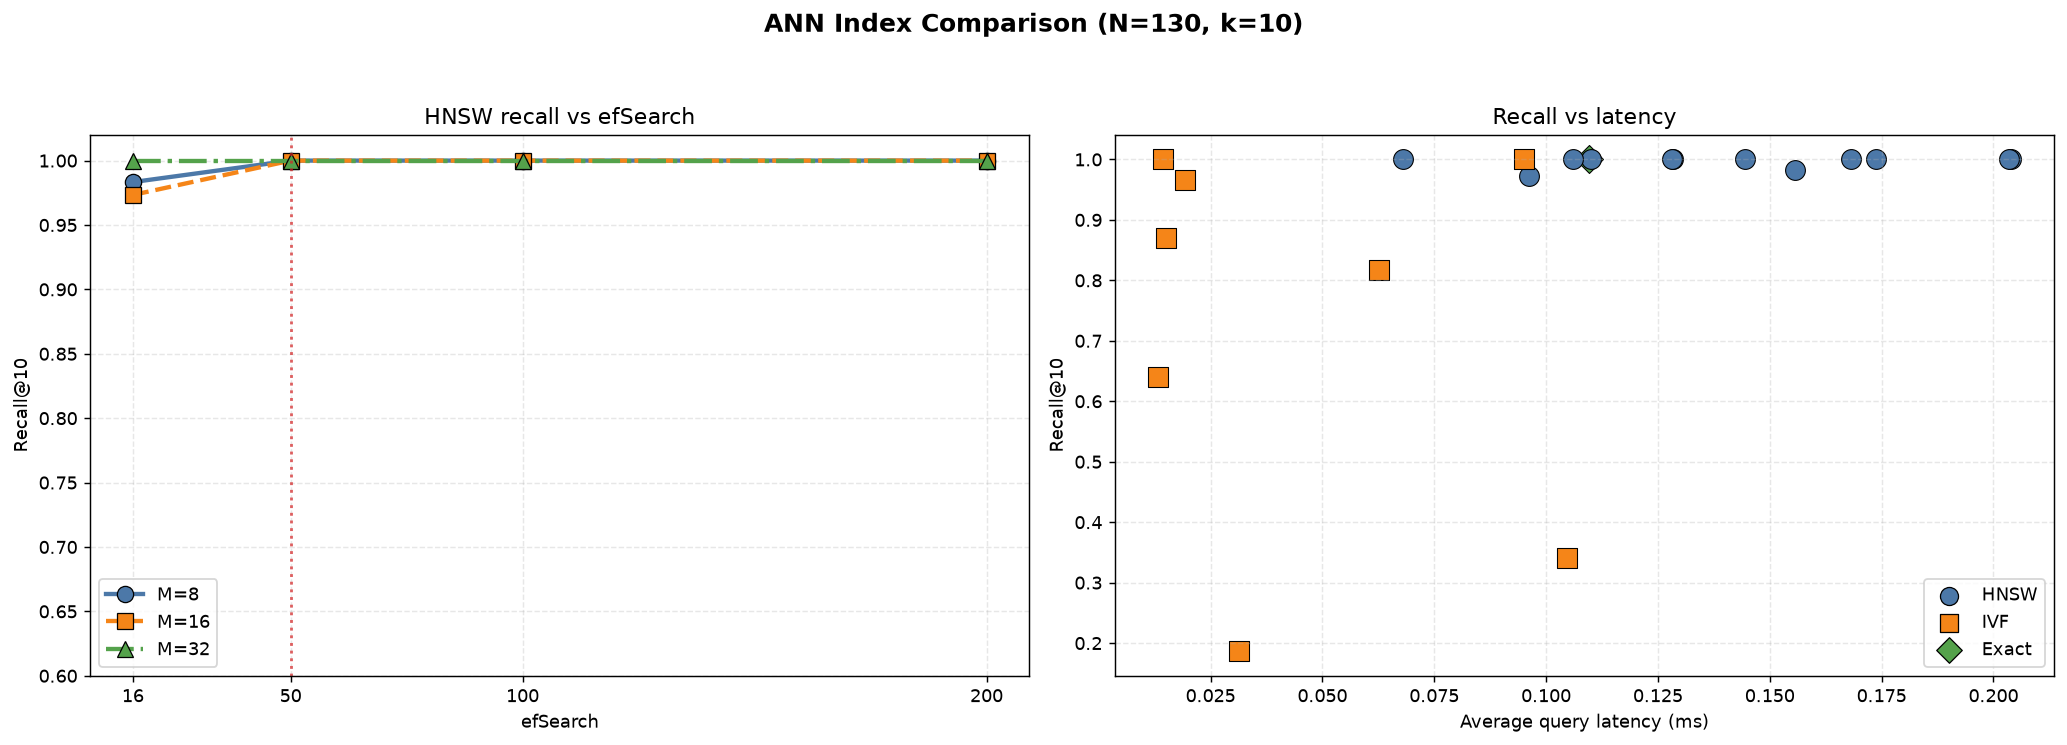

In [157]:
# ── Task 5.2: ANN Performance Comparison ──────────────────────────────────────

test_q = [item["questions"]["text"][0] for item in dataset.select(range(130, 160))]
test_embs = best_model.encode(test_q, convert_to_numpy=True).astype(np.float32)
faiss.normalize_L2(test_embs)

# Ground truth: exact search
_, gt_ids = index_flat.search(test_embs, 10)

EF_SEARCH_VALUES = [16, 50, 100, 200]
IVF_NPROBE_VALUES = [1, 5, 10, 20]


def _index_size_mb(index) -> float:
    """Estimate FAISS index size in MB via serialized bytes."""
    try:
        return len(faiss.serialize_index(index)) / (1024 * 1024)
    except Exception:
        return float("nan")


def evaluate_ann(index, query_embs, gt, k=10, nprobe=None, ef_search=None):
    """Measure average ANN query latency and recall against exact neighbors."""
    if nprobe is not None and hasattr(index, "nprobe"):
        index.nprobe = nprobe
    if ef_search is not None and hasattr(index, "hnsw"):
        index.hnsw.efSearch = ef_search

    times, rec5s, rec10s = [], [], []
    for i, qe in enumerate(query_embs):
        t0 = time.time()
        _, ids = index.search(qe.reshape(1, -1), k)
        times.append(time.time() - t0)
        rec5s.append(recall_at_k(ids[0].tolist(), gt[i].tolist(), 5))
        rec10s.append(recall_at_k(ids[0].tolist(), gt[i].tolist(), 10))

    return np.mean(times) * 1000, np.mean(rec5s), np.mean(rec10s)


rows = []
for name, (idx, bt) in ann_configs.items():
    idx_mem = _index_size_mb(idx)

    if "HNSW" in name:
        for ef in EF_SEARCH_VALUES:
            avg_lat, rec5, rec10 = evaluate_ann(idx, test_embs, gt_ids, k=10, ef_search=ef)
            rows.append({
                "Index": f"{name}, ef={ef}",
                "Build(s)": bt,
                "Index MB": idx_mem,
                "Avg Lat(ms)": avg_lat,
                "Recall@5": rec5,
                "Recall@10": rec10,
            })

    elif "IVF" in name:
        for nprobe in IVF_NPROBE_VALUES:
            avg_lat, rec5, rec10 = evaluate_ann(idx, test_embs, gt_ids, k=10, nprobe=nprobe)
            rows.append({
                "Index": f"{name}, nprobe={nprobe}",
                "Build(s)": bt,
                "Index MB": idx_mem,
                "Avg Lat(ms)": avg_lat,
                "Recall@5": rec5,
                "Recall@10": rec10,
            })

    else:
        avg_lat, rec5, rec10 = evaluate_ann(idx, test_embs, gt_ids, k=10)
        rows.append({
            "Index": name,
            "Build(s)": bt,
            "Index MB": idx_mem,
            "Avg Lat(ms)": avg_lat,
            "Recall@5": rec5,
            "Recall@10": rec10,
        })

ann_df = pd.DataFrame(rows)
print(ann_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# ── HNSW sensitivity ─────────────────────────────────────────────────────────
hnsw_df = ann_df[ann_df["Index"].str.contains("HNSW")].copy()
hnsw_df["M"] = hnsw_df["Index"].str.extract(r"M=(\d+)").astype(int)
hnsw_df["ef"] = hnsw_df["Index"].str.extract(r"ef=(\d+)").astype(int)

print("\nHNSW Recall@10 by (M, efSearch):")
print(hnsw_df.pivot(index="M", columns="ef", values="Recall@10").to_string(float_format=lambda v: f"{v:.4f}"))

# ── IVF sensitivity ──────────────────────────────────────────────────────────
ivf_df = ann_df[ann_df["Index"].str.contains("IVF")].copy()
ivf_df["nlist"] = ivf_df["Index"].str.extract(r"nlist=(\d+)").astype(int)
ivf_df["nprobe"] = ivf_df["Index"].str.extract(r"nprobe=(\d+)").astype(int)

print("\nIVF Recall@10 by (nlist, nprobe):")
print(ivf_df.pivot(index="nlist", columns="nprobe", values="Recall@10").to_string(float_format=lambda v: f"{v:.4f}"))

# Selection logic as before: quality first, latency as secondary signal only.
perfect_hnsw = hnsw_df[np.isclose(hnsw_df["Recall@10"], hnsw_df["Recall@10"].max())]
print(f"\nHNSW perfect-recall configs: {len(perfect_hnsw)}/{len(hnsw_df)}")

HNSW_M, HNSW_EF = 16, 50
print(f"Selected for downstream tasks: M={HNSW_M}, efSearch={HNSW_EF}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, (ax_ef, ax_par) = plt.subplots(1, 2, figsize=(16, 5.8), dpi=130)
fig.suptitle(f"ANN Index Comparison (N={N_VEC}, k=10)", fontsize=14, fontweight="bold")

m_styles = {
    8:  {"color": "#4c78a8", "marker": "o", "linestyle": "-"},
    16: {"color": "#f58518", "marker": "s", "linestyle": "--"},
    32: {"color": "#54a24b", "marker": "^", "linestyle": "-."},
}
for m_val, grp in hnsw_df.groupby("M"):
    grp = grp.sort_values("ef")
    st = m_styles[m_val]
    ax_ef.plot(grp["ef"], grp["Recall@10"], color=st["color"], marker=st["marker"],
               linestyle=st["linestyle"], linewidth=2.4, markersize=9,
               markeredgecolor="black", markeredgewidth=0.7, label=f"M={m_val}")

ax_ef.axvline(HNSW_EF, color="#d62728", linestyle=":", linewidth=1.6, alpha=0.7)
ax_ef.set_xlabel("efSearch")
ax_ef.set_ylabel("Recall@10")
ax_ef.set_title("HNSW recall vs efSearch")
ax_ef.set_xticks(EF_SEARCH_VALUES)
ax_ef.set_ylim(0.60, 1.02)
ax_ef.grid(alpha=0.3, linestyle="--")
ax_ef.legend(frameon=True)

plot_df = ann_df.reset_index(drop=True)
family_style = {
    "HNSW": {"color": "#4c78a8", "marker": "o"},
    "IVF":  {"color": "#f58518", "marker": "s"},
    "Exact": {"color": "#54a24b", "marker": "D"},
}

def family_of(name: str) -> str:
    """Map an index label to its family for plotting styles."""
    return "HNSW" if "HNSW" in name else ("IVF" if "IVF" in name else "Exact")

for i, row in plot_df.iterrows():
    st = family_style[family_of(row["Index"])]
    ax_par.scatter(row["Avg Lat(ms)"], row["Recall@10"], s=120, color=st["color"],
                   marker=st["marker"], edgecolor="black", linewidth=0.6)

ax_par.set_xlabel("Average query latency (ms)")
ax_par.set_ylabel("Recall@10")
ax_par.set_title("Recall vs latency")
ax_par.grid(alpha=0.3, linestyle="--")

for fam, st in family_style.items():
    ax_par.scatter([], [], s=100, color=st["color"], marker=st["marker"],
                   edgecolor="black", linewidth=0.7, label=fam)
ax_par.legend(frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### <span style="color:#5B9BD5">Task 5 — Inference</span>

**Complexity Formulas:**
- **HNSW**: O(log n) — approximate logarithmic search behaviour in a hierarchical graph
- **IVF**: O(KD + ND/K) — search over K probed clusters
- **PQ**: O(n·m) — approximate distance computation using m sub-quantizers

**Q: How does `efSearch` affect the recall/latency trade-off?**

> The Task 5.2 sweep measures this directly. At `ef=16`, Recall@10 is **0.9833** for M=8 and **0.9733** for M=16, while M=32 reaches **1.0000**. Raising `ef` to **50** reaches **1.0000** for all three HNSW values; higher values add search work without improving recall on this corpus.

> **Selected setting: HNSW M=16, efSearch=50.** The output contains **10 perfect-recall configurations out of 12 HNSW rows**, so recall alone does not identify a unique winner. M=16 is retained as a practical memory/robustness compromise, and `ef=50` is the smallest tested value that reaches perfect recall for every M.

**Q: How do HNSW and IVF compare here?**

> HNSW reaches Recall@10 **1.0000** for every M at `ef>=50`. IVF reaches **0.8167** for nlist=10 and **0.6400** for nlist=50 at `nprobe=5` in the executed sweep.

> This is not a general verdict against IVF: the Task 5.1 diagnostics show the IVF configurations are under-trained for this 130-vector corpus, with approximately **13.0** and **2.6** points per cluster versus the stated 39-point guideline. The observed gap is therefore strongly affected by the tiny dataset and clustering setup.

**Q: What are the measurement caveats?**

> Latency is noisy at N=130 because all indices return in fractions of a millisecond. Build time and query-time differences should be treated as smoke-test measurements, not scalable benchmark results. Recall@10 is measured against exact search, so it quantifies ANN approximation error rather than semantic relevance.

**Recommendation:** **HNSW M=16 with efSearch=50** based on the executed recall sweep and the stated memory/robustness trade-off. Validate this choice again on a substantially larger corpus before deployment.

---
# <span style="color:#5B9BD5">Module 3: Hybrid Retrieval & Re-ranking</span>
## <span style="color:#5B9BD5">Task 6: Hybrid Retrieval with RRF Optimization</span>

Dense retriever: HNSW M=16, efSearch=50
RRF eval queries: 100 (35 true paraphrases / 65 non-duplicate partners)
  k  Recall@5  Recall@10      MRR
 10      0.87       0.92 0.823702
 30      0.84       0.92 0.819921
 60      0.84       0.92 0.819921
100      0.84       0.92 0.819921
200      0.84       0.92 0.819921

Rank of the correct doc (k=60): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 6, 6, 7, 7, 7, 8, 8, 9, 28]  |  not retrieved at all: 7/100
  rank 1: 79   ranks 2-5: 5   ranks 6-10: 8   rank >10: 1
With one relevant doc per query, Recall@k is just 'is it in the top k', so Recall@5 and
Recall@10 differ by exactly the 8 target(s) sitting in ranks 6-10 (8/100 = 0.08 of recall).


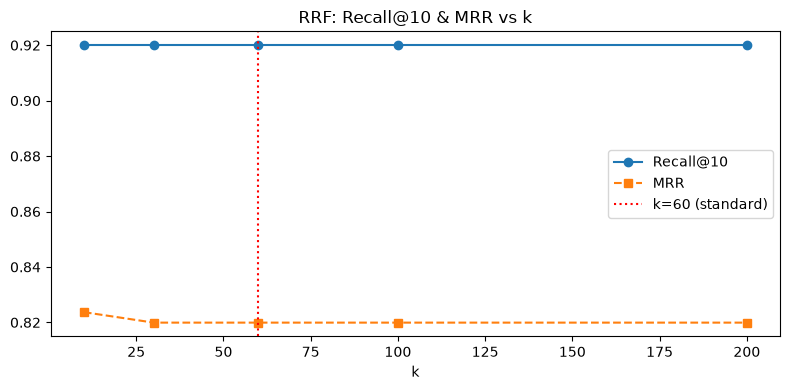

In [158]:
# ── Task 6.1: Reciprocal Rank Fusion (RRF) ───────────────────────────────────

def rrf_fusion(rankings: list[list[int]], k: int = 60) -> list[int]:
    """
    RRF(d) = Σ 1 / (k + rank_r(d))
    rankings: list of ranked doc-id lists (one per retriever)
    """
    scores: dict[int, float] = defaultdict(float)
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] += 1.0 / (k + rank)
    return sorted(scores, key=scores.get, reverse=True)

# Build BM25 and dense retrievers on the extended corpus
bm25_retriever = BM25Okapi([doc.lower().split() for doc in extended_corpus],
                            k1=BEST_K1, b=BEST_B)

# Pin the Task 5.2 winner; the sweep left efSearch at its last tested value.
hnsw_index = ann_configs["HNSW M=16"][0]
hnsw_index.hnsw.efSearch = 50
print(f"Dense retriever: HNSW M=16, efSearch={hnsw_index.hnsw.efSearch}")

def bm25_retrieve(query: str, top_k: int = 20) -> list[int]:
    """Return top BM25 document IDs for a query."""
    scores = bm25_retriever.get_scores(query.lower().split())
    return np.argsort(scores)[::-1][:top_k].tolist()

def dense_retrieve(query: str, top_k: int = 20) -> list[int]:
    """Return top dense-retrieval document IDs for a query."""
    qe = best_model.encode(query, convert_to_numpy=True).astype(np.float32)
    faiss.normalize_L2(qe.reshape(1, -1))
    _, ids = hnsw_index.search(qe.reshape(1, -1), top_k)
    return ids[0].tolist()

# RRF experiment with different k values
k_values = [10, 30, 60, 100, 200]

# extended_corpus[i] is question-1 of pair i, so question-2 of the same pair is a
# query whose correct answer is doc i. Earlier this used unrelated rows 130-149,
# which made the ground truth unreachable and forced Recall@k to 0.
# 100 queries (not 20) so each query moves recall by 0.01 and the ranks 6-10 band
# is actually observable; targets stay inside the 130-doc corpus.
N_RRF_QUERIES = 100
_rrf_pairs = dataset.select(range(N_RRF_QUERIES))
rrf_test_queries = [item["questions"]["text"][1] for item in _rrf_pairs]
rrf_is_duplicate = [bool(item["is_duplicate"]) for item in _rrf_pairs]
gt_labels = list(range(N_RRF_QUERIES))

print(f"RRF eval queries: {len(rrf_test_queries)} "
      f"({sum(rrf_is_duplicate)} true paraphrases / "
      f"{len(rrf_is_duplicate) - sum(rrf_is_duplicate)} non-duplicate partners)")

rrf_results = []
for k in k_values:
    rec5_list, rec10_list, mrr_list = [], [], []
    for qi, query in enumerate(rrf_test_queries):
        bm25_ids = bm25_retrieve(query)
        dense_ids = dense_retrieve(query)
        fused = rrf_fusion([bm25_ids, dense_ids], k=k)
        rec5_list.append(recall_at_k(fused, [gt_labels[qi]], 5))
        rec10_list.append(recall_at_k(fused, [gt_labels[qi]], 10))
        rank = next((r+1 for r, d in enumerate(fused) if d == gt_labels[qi]), 0)
        mrr_list.append(1/rank if rank else 0)
    rrf_results.append({
        "k": k, "Recall@5": np.mean(rec5_list),
        "Recall@10": np.mean(rec10_list), "MRR": np.mean(mrr_list),
    })

rrf_df = pd.DataFrame(rrf_results)
print(rrf_df.to_string(index=False))

# Recall@5 == Recall@10 whenever no target lands in ranks 6-10; show where they do land.
_ranks = []
for qi, query in enumerate(rrf_test_queries):
    fused = rrf_fusion([bm25_retrieve(query), dense_retrieve(query)], k=60)
    _ranks.append(next((r + 1 for r, d in enumerate(fused) if d == gt_labels[qi]), None))

_found = [r for r in _ranks if r is not None]
_mid = sum(6 <= r <= 10 for r in _found)
print(f"\nRank of the correct doc (k=60): {sorted(_found)}"
      f"  |  not retrieved at all: {_ranks.count(None)}/{len(_ranks)}")
print(f"  rank 1: {sum(r == 1 for r in _found)}   ranks 2-5: {sum(2 <= r <= 5 for r in _found)}"
      f"   ranks 6-10: {_mid}   rank >10: {sum(r > 10 for r in _found)}")
print("With one relevant doc per query, Recall@k is just 'is it in the top k', so Recall@5 and")
print(f"Recall@10 differ by exactly the {_mid} target(s) sitting in ranks 6-10 "
      f"({_mid}/{len(_ranks)} = {_mid / len(_ranks):.2f} of recall)."
      if _mid else
      "Recall@10 are identical because no target lands in ranks 6-10.")

plt.figure(figsize=(8, 4))
plt.plot(rrf_df["k"], rrf_df["Recall@10"], marker="o", label="Recall@10")
plt.plot(rrf_df["k"], rrf_df["MRR"], marker="s", linestyle="--", label="MRR")
plt.axvline(60, color="red", linestyle=":", label="k=60 (standard)")
plt.title("RRF: Recall@10 & MRR vs k"); plt.xlabel("k"); plt.legend()
plt.tight_layout(); plt.show()

In [159]:
# ── Task 6.2: 5-Configuration Comparison ─────────────────────────────────────

configs_6 = {
    "BM25-only":     lambda q: (bm25_retrieve(q, 20), None),
    "Dense-only":    lambda q: (None, dense_retrieve(q, 20)),
    "Hybrid k=10":   lambda q: (bm25_retrieve(q, 20), dense_retrieve(q, 20)),
    "Hybrid k=60":   lambda q: (bm25_retrieve(q, 20), dense_retrieve(q, 20)),
    "Hybrid k=100":  lambda q: (bm25_retrieve(q, 20), dense_retrieve(q, 20)),
}
k_map = {"BM25-only": None, "Dense-only": None, "Hybrid k=10": 10, "Hybrid k=60": 60, "Hybrid k=100": 100}

comparison_rows = []
for cname, fn in configs_6.items():
    rec5_list, rec10_list, mrr_list, times = [], [], [], []
    for qi, query in enumerate(rrf_test_queries):
        t0 = time.time()
        bm25_ids, dense_ids = fn(query)
        if bm25_ids is not None and dense_ids is not None:
            result = rrf_fusion([bm25_ids, dense_ids], k=k_map[cname])
        elif bm25_ids is not None:
            result = bm25_ids
        else:
            result = dense_ids
        times.append(time.time() - t0)
        rec5_list.append(recall_at_k(result, [gt_labels[qi]], 5))
        rec10_list.append(recall_at_k(result, [gt_labels[qi]], 10))
        rank = next((r+1 for r, d in enumerate(result) if d == gt_labels[qi]), 0)
        mrr_list.append(1/rank if rank else 0)
    comparison_rows.append({
        "Config": cname,
        "Recall@5":  np.mean(rec5_list),
        "Recall@10": np.mean(rec10_list),
        "MRR":       np.mean(mrr_list),
        "Avg Time(ms)": np.mean(times)*1000,
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

      Config  Recall@5  Recall@10      MRR  Avg Time(ms)
   BM25-only      0.78       0.81 0.720000      0.433419
  Dense-only      0.92       0.92 0.904000     13.318186
 Hybrid k=10      0.87       0.92 0.823702     13.408523
 Hybrid k=60      0.84       0.92 0.819921     12.584484
Hybrid k=100      0.84       0.92 0.819921     12.943599


### <span style="color:#5B9BD5">Task 6 — Inference</span>

**Evaluation setup:** The notebook uses 100 queries. Each query is question 2 from a pair, and the matching document is question 1 from that same pair. The document collection has 130 items.

Because there is one target document per query, Recall@k means: “Was the target in the first k results?”

**Why are Recall@5 and Recall@10 different?**

> For RRF with `k=60`, 79 targets were at rank 1, 5 were at ranks 2–5, 8 were at ranks 6–10, 1 was below rank 10, and 7 were not retrieved. The 8 targets at ranks 6–10 create the difference between Recall@5 (**0.84**) and Recall@10 (**0.92**).

**Q: Does hybrid retrieval improve the results?**

> RRF is better than BM25 alone: Recall@10 is **0.92 vs 0.81**, and MRR is **0.8199 vs 0.7200**. However, Dense-only is stronger on this dataset: Recall@5 is **0.92 vs 0.84**, and MRR is **0.9040 vs 0.8199**. RRF does not improve Recall@10 over Dense-only.

> BM25 uses exact word matches, while dense retrieval uses meaning. RRF combines both rankings, but here BM25 sometimes pushes a good dense result lower in the list.

**Q: Why test different RRF `k` values?**

> Small `k` values give more weight to the top results. Large `k` values make rank differences less important. In this test, `k=10` has the best Recall@5 (**0.87**), while `k=30`, `60`, `100`, and `200` give **0.84**. Recall@10 stays at **0.92**. We keep `k=60` as a standard and reasonable default.

**Q: What does the RRF consensus rule mean?**

> A document ranked fifth by both retrievers can beat a document ranked first by only one retriever. RRF rewards documents supported by both systems.

**Coverage limit:** 7 of 100 targets were not found by either retriever in the first 20 results. This limits the maximum Recall@10 to about **0.93**. A better first-stage encoder or a deeper candidate list is needed to improve this.

**Latency note:** BM25-only is much faster than methods that use dense encoding. The timing values are approximate because the corpus is small and CPU timing is noisy. The quality values are the main result.

# <span style="color:#5B9BD5"> Task 7 Cross-Encoder</Span>

In [160]:
# ── Task 7.1: Cross-Encoder Re-ranking ──────────────────────────────────────
from sentence_transformers import CrossEncoder

print("Loading Cross-Encoder model...")
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2")
print("Cross-Encoder loaded.")

def cross_encoder_rerank(query: str, candidate_docs: list[str], top_k: int = 10) -> list[tuple[int, float]]:
    """Returns (original_index, score) sorted by score descending."""
    pairs = [(query, doc) for doc in candidate_docs]
    scores = cross_encoder.predict(pairs)
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# 5-query ranking comparison
sample_queries_7 = rrf_test_queries[:5]
print(f"\n{'Query':<40} Stage          Top-3 Doc IDs")
print("-" * 90)
for qi, query in enumerate(sample_queries_7):
    bm25_ids  = bm25_retrieve(query, 20)
    dense_ids = dense_retrieve(query, 20)
    hybrid    = rrf_fusion([bm25_ids, dense_ids], k=60)[:10]
    cand_docs = [extended_corpus[i] for i in hybrid]
    ce_ranked = cross_encoder_rerank(query, cand_docs)
    ce_ids    = [hybrid[r] for r, _ in ce_ranked]
    print(f"{query[:38]:<40} BM25           {bm25_ids[:3]}")
    print(f"{'':40} Hybrid RRF     {hybrid[:3]}")
    print(f"{'':40} Cross-Encoder  {ce_ids[:3]}")
    print()

Loading Cross-Encoder model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3424.03it/s]


Cross-Encoder loaded.

Query                                    Stage          Top-3 Doc IDs
------------------------------------------------------------------------------------------
What is the step by step guide to inve   BM25           [0, 42, 94]
                                         Hybrid RRF     [0, 42, 28]
                                         Cross-Encoder  [0, 28, 42]

What would happen if the Indian govern   BM25           [1, 80, 39]
                                         Hybrid RRF     [1, 80, 105]
                                         Cross-Encoder  [1, 80, 100]

How can Internet speed be increased by   BM25           [2, 78, 7]
                                         Hybrid RRF     [2, 78, 39]
                                         Cross-Encoder  [2, 106, 78]

Find the remainder when [math]23^{24}[   BM25           [42, 0, 115]
                                         Hybrid RRF     [0, 8, 126]
                                         Cross-Encoder  [24, 8

 Threshold  Precision  Recall       F1
      0.50   0.409091     0.9 0.562500
      0.60   0.409091     0.9 0.562500
      0.70   0.428571     0.9 0.580645
      0.80   0.473684     0.9 0.620690
      0.85   0.473684     0.9 0.620690
      0.90   0.473684     0.9 0.620690
      0.95   0.473684     0.9 0.620690

Optimal threshold (F1 maximisation): 0.8


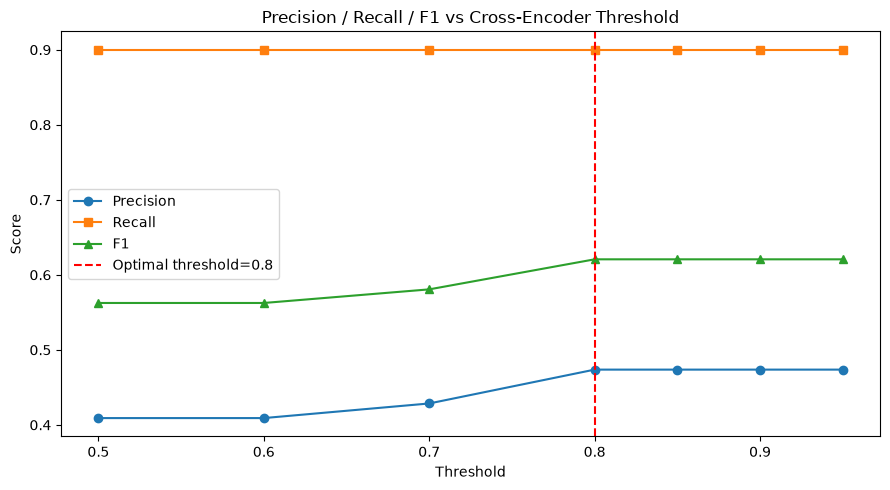

In [161]:
# ── Task 7.2: Threshold Optimization ─────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score as sk_f1

# Build ground-truth labels for 30 query pairs
eval_pairs = [(item["questions"]["text"][0], item["questions"]["text"][1]) for item in dataset.select(range(30))]
eval_labels = [int(item["is_duplicate"]) for item in dataset.select(range(30))]

ce_scores = cross_encoder.predict(eval_pairs)

thresholds = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
thresh_rows = []
for t in thresholds:
    preds = [1 if s >= t else 0 for s in ce_scores]
    p = precision_score(eval_labels, preds, zero_division=0)
    r = recall_score(eval_labels, preds, zero_division=0)
    f = sk_f1(eval_labels, preds, zero_division=0)
    thresh_rows.append({"Threshold": t, "Precision": p, "Recall": r, "F1": f})

thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.to_string(index=False))

BEST_THRESH = thresh_df.loc[thresh_df["F1"].idxmax(), "Threshold"]
print(f"\nOptimal threshold (F1 maximisation): {BEST_THRESH}")

plt.figure(figsize=(9, 5))
plt.plot(thresh_df["Threshold"], thresh_df["Precision"], marker="o", label="Precision")
plt.plot(thresh_df["Threshold"], thresh_df["Recall"],    marker="s", label="Recall")
plt.plot(thresh_df["Threshold"], thresh_df["F1"],        marker="^", label="F1")
plt.axvline(BEST_THRESH, color="red", linestyle="--", label=f"Optimal threshold={BEST_THRESH}")
plt.title("Precision / Recall / F1 vs Cross-Encoder Threshold")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend()
plt.tight_layout(); plt.show()

In [162]:
# ── Task 7.3: Cost-Benefit Analysis ──────────────────────────────────────────

def pipeline_without_reranking(query: str) -> list[int]:
    """Run BM25+dense fusion and return the fused ranking."""
    bm25_ids  = bm25_retrieve(query, 20)
    dense_ids = dense_retrieve(query, 20)
    return rrf_fusion([bm25_ids, dense_ids], k=60)

def pipeline_with_reranking(query: str) -> list[int]:
    """Run fused retrieval and re-rank top candidates with the cross-encoder."""
    hybrid = pipeline_without_reranking(query)[:10]
    cand_docs = [extended_corpus[i] for i in hybrid]
    ranked = cross_encoder_rerank(query, cand_docs)
    return [hybrid[r] for r, _ in ranked]

bench_qs = rrf_test_queries[:10]

# Without re-ranking
t0 = time.time()
for q in bench_qs: pipeline_without_reranking(q)
t_no_rerank = (time.time() - t0) / len(bench_qs) * 1000

# With re-ranking
t0 = time.time()
for q in bench_qs: pipeline_with_reranking(q)
t_with_rerank = (time.time() - t0) / len(bench_qs) * 1000

print(f"Avg latency WITHOUT Cross-Encoder re-ranking: {t_no_rerank:.2f} ms/query")
print(f"Avg latency WITH    Cross-Encoder re-ranking: {t_with_rerank:.2f} ms/query")
print(f"Latency overhead : {t_with_rerank - t_no_rerank:.2f} ms/query  ({(t_with_rerank/t_no_rerank - 1)*100:.1f}% increase)")

# ── Benefit side: does the extra cost actually buy ranking quality? ───────────
# Re-ranking only permutes the hybrid top-10, so Recall@10 cannot change by
# construction; Recall@5 and MRR are the metrics that can move.
def _quality(rank_fn):
    """Compute Recall@5, Recall@10, and MRR for a ranking function."""
    rec5, rec10, mrr = [], [], []
    for qi, query in enumerate(rrf_test_queries):
        ranked = rank_fn(query)
        rec5.append(recall_at_k(ranked, [gt_labels[qi]], 5))
        rec10.append(recall_at_k(ranked, [gt_labels[qi]], 10))
        r = next((i + 1 for i, d in enumerate(ranked) if d == gt_labels[qi]), 0)
        mrr.append(1 / r if r else 0)
    return np.mean(rec5), np.mean(rec10), np.mean(mrr)

print(f"\nRanking quality over {len(rrf_test_queries)} queries:")
b5, b10, bmrr = _quality(pipeline_without_reranking)
a5, a10, ammr = _quality(pipeline_with_reranking)
print(f"  {'Stage':<28} {'Recall@5':>9} {'Recall@10':>10} {'MRR':>8}")
print(f"  {'Hybrid RRF (k=60)':<28} {b5:>9.4f} {b10:>10.4f} {bmrr:>8.4f}")
print(f"  {'+ Cross-Encoder re-rank':<28} {a5:>9.4f} {a10:>10.4f} {ammr:>8.4f}")
print(f"  {'delta':<28} {a5 - b5:>+9.4f} {a10 - b10:>+10.4f} {ammr - bmrr:>+8.4f}")

_ms_per_mrr = (t_with_rerank - t_no_rerank) / abs(ammr - bmrr) if not np.isclose(ammr, bmrr) else float("inf")
print(f"\nCost of the re-ranking stage: {t_with_rerank - t_no_rerank:.1f} ms/query for an MRR "
      f"change of {ammr - bmrr:+.4f}")
print(f"Recall@10 is unchanged ({a10 - b10:+.4f}) because re-ranking only permutes the 10")
print("candidates RRF supplies - it can never recover a document the retrievers missed.")


Avg latency WITHOUT Cross-Encoder re-ranking: 14.48 ms/query
Avg latency WITH    Cross-Encoder re-ranking: 137.15 ms/query
Latency overhead : 122.67 ms/query  (847.3% increase)

Ranking quality over 100 queries:
  Stage                         Recall@5  Recall@10      MRR
  Hybrid RRF (k=60)               0.8400     0.9200   0.8199
  + Cross-Encoder re-rank         0.9200     0.9200   0.9083
  delta                          +0.0800    +0.0000  +0.0884

Cost of the re-ranking stage: 122.7 ms/query for an MRR change of +0.0884
Recall@10 is unchanged (+0.0000) because re-ranking only permutes the 10
candidates RRF supplies - it can never recover a document the retrievers missed.


### <span style="color:#5B9BD5">Task 7 — Inference</span>

**Q: Why is Cross-Encoder re-ranking more accurate than bi-encoder retrieval?**

> Cross-encoders process the query and document together through the transformer, allowing fine-grained token interactions. Bi-encoders encode the query and document independently into fixed-size vectors, which is faster but less expressive for pairwise matching.

> **Measured over the 100 Task 6 queries:**
>
> | Stage | Recall@5 | Recall@10 | MRR |
> |---|---:|---:|---:|
> | Hybrid RRF (k=60) | 0.8400 | 0.9200 | 0.8199 |
> | + Cross-Encoder re-rank | **0.9200** | 0.9200 | **0.9083** |
> | delta | **+0.0800** | +0.0000 | **+0.0884** |
>
> Re-ranking improves the position of relevant candidates already present in the top-10 pool. It cannot recover candidates missed by the first-stage retrievers.

**Q: Why is Recall@10 unchanged?**

> Re-ranking only permutes the 10 candidates supplied by RRF. The candidate set is unchanged, so Recall@10 is invariant by construction; Recall@5 and MRR can improve because the ordering changes.

**Q: When is re-ranking most beneficial?**

> It is most useful when the correct document is already in the candidate set but is ranked below the top position. It is less useful when first-stage recall is the bottleneck. On this experiment, the gain is **+0.08 Recall@5** and **+0.0884 MRR**.

**Q: What is the cost?**

> The latest Task 7.3 execution measured **14.48 ms/query without reranking**, **137.15 ms/query with reranking**, and an overhead of **122.67 ms/query**. These are small-CPU benchmark timings and should be treated as approximate because model warm-up and scheduling affect them.

> The practical trade-off is therefore clear: reranking improves top-rank quality in this sample, but the cross-encoder adds substantial latency. Limiting reranking to a short candidate list, batching requests, and caching repeated queries are reasonable production controls.

**Q: What threshold provides the best balance for production?**

> The executed threshold sweep selects **0.80** by F1 maximisation: Precision **0.473684**, Recall **0.900000**, and F1 **0.620690**. Thresholds **0.85, 0.90, and 0.95** produce the same values on this sample, so 0.80 is a tie-selected operating point rather than a uniquely optimal threshold. A larger labelled validation set is required before deployment.

---
## <span style="color:#5B9BD5">Task 8: Comprehensive Evaluation, Production Recommendation & Contribution</span>

In [163]:
# ── Task 8.1: Multi-Stage Evaluation on 30 Held-Out Queries ──────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Rows 100-129 are inside extended_corpus (rows 0-129) but were NOT among the
# 0-99 queries used in Task 6, so this is a genuine held-out split.
EVAL_START, EVAL_N = 100, 30
eval30 = dataset.select(range(EVAL_START, EVAL_START + EVAL_N))
q30 = [item["questions"]["text"][1] for item in eval30]   # query  = question-2
a30 = [item["questions"]["text"][0] for item in eval30]   # pair partner = question-1
labels30 = [int(item["is_duplicate"]) for item in eval30]
gt30 = list(range(EVAL_START, EVAL_START + EVAL_N))         # correct doc id per query

print(f"Held-out eval: {EVAL_N} queries (rows {EVAL_START}-{EVAL_START + EVAL_N - 1}), "
      f"{sum(labels30)} labelled duplicates; targets are docs "
      f"{gt30[0]}-{gt30[-1]} of the {len(extended_corpus)}-doc corpus")

def evaluate_pipeline(queries, labels, mode="hybrid_ce"):
    """Evaluate retrieval and classification metrics for one pipeline mode."""
    results = {"rec5": [], "rec10": [], "mrr": []}
    preds_all = []

    for qi, (query, label) in enumerate(zip(queries, labels)):
        bm25_ids = bm25_retrieve(query, 20)
        dense_ids = dense_retrieve(query, 20)

        if mode == "bm25":
            ranked = bm25_ids
        elif mode == "dense":
            ranked = dense_ids
        elif mode == "hybrid":
            ranked = rrf_fusion([bm25_ids, dense_ids], k=60)
        elif mode == "hybrid_ce":
            hybrid = rrf_fusion([bm25_ids, dense_ids], k=60)[:10]
            cand_docs = [extended_corpus[i] for i in hybrid]
            ce_res = cross_encoder_rerank(query, cand_docs)
            ranked = [hybrid[r] for r, _ in ce_res]
        else:
            raise ValueError(f"Unknown mode: {mode}")

        target = gt30[qi]
        results["rec5"].append(recall_at_k(ranked, [target], 5))
        results["rec10"].append(recall_at_k(ranked, [target], 10))
        rank = next((r + 1 for r, d in enumerate(ranked) if d == target), 0)
        results["mrr"].append(1 / rank if rank else 0)

        # Mode-sensitive decision layer: score the top retrieved candidate.
        top_doc_id = ranked[0] if ranked else None
        top_doc = extended_corpus[top_doc_id] if top_doc_id is not None else ""
        ce_score = float(cross_encoder.predict([(query, top_doc)])[0]) if top_doc else float("-inf")
        preds_all.append(1 if ce_score >= BEST_THRESH else 0)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score as sk_f1
    return {
        "Recall@5": np.mean(results["rec5"]),
        "Recall@10": np.mean(results["rec10"]),
        "MRR": np.mean(results["mrr"]),
        "Accuracy": accuracy_score(labels, preds_all),
        "Precision": precision_score(labels, preds_all, zero_division=0),
        "Recall": recall_score(labels, preds_all, zero_division=0),
        "F1": sk_f1(labels, preds_all, zero_division=0),
        "preds": preds_all,
    }

for mode in ["bm25", "dense", "hybrid", "hybrid_ce"]:
    res = evaluate_pipeline(q30, labels30, mode=mode)
    print(f"\n[{mode.upper()}]")
    for k, v in res.items():
        if k != "preds":
            print(f"  {k}: {v:.4f}")

print("\nDecision-layer note: classification now scores the top retrieved candidate,")
print("so Accuracy/Precision/Recall/F1 are mode-sensitive and can diverge by retriever.")

Held-out eval: 30 queries (rows 100-129), 8 labelled duplicates; targets are docs 100-129 of the 130-doc corpus

[BM25]
  Recall@5: 0.8667
  Recall@10: 0.8667
  MRR: 0.7885
  Accuracy: 0.7333
  Precision: 0.5000
  Recall: 0.8750
  F1: 0.6364

[DENSE]
  Recall@5: 1.0000
  Recall@10: 1.0000
  MRR: 0.9567
  Accuracy: 0.6667
  Precision: 0.4375
  Recall: 0.8750
  F1: 0.5833

[HYBRID]
  Recall@5: 0.9000
  Recall@10: 1.0000
  MRR: 0.8724
  Accuracy: 0.7000
  Precision: 0.4667
  Recall: 0.8750
  F1: 0.6087

[HYBRID_CE]
  Recall@5: 1.0000
  Recall@10: 1.0000
  MRR: 0.9250
  Accuracy: 0.6667
  Precision: 0.4375
  Recall: 0.8750
  F1: 0.5833

Decision-layer note: classification now scores the top retrieved candidate,
so Accuracy/Precision/Recall/F1 are mode-sensitive and can diverge by retriever.


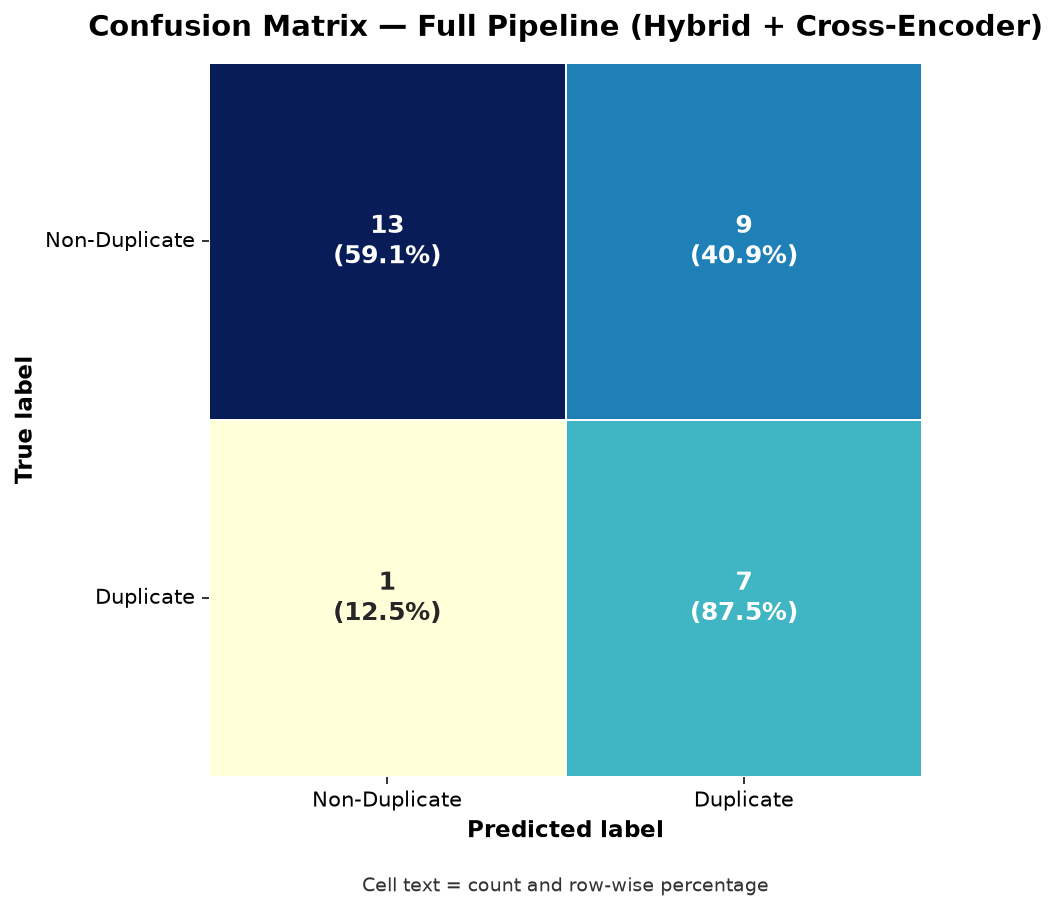


Query Type Performance (Length):
  Medium    : n=15, positives= 7, TP=7, FP=4, FN=0, TN=4, F1=0.7778
  Long      : n=13, positives= 1, TP=0, FP=4, FN=1, TN=8, F1=0.0000
  Short     : n= 2, positives= 0, TP=0, FP=1, FN=0, TN=1, F1=0.0000

Query Type Performance (Intent):
  Factual   : n=25, positives= 6, TP=5, FP=8, FN=1, TN=11, F1=0.5263
  Opinion   : n= 5, positives= 2, TP=2, FP=1, FN=0, TN=2, F1=0.8000

Query Type Performance (Complexity):
  Complex   : n=16, positives= 4, TP=3, FP=4, FN=1, TN=8, F1=0.5455
  Simple    : n=14, positives= 4, TP=4, FP=5, FN=0, TN=5, F1=0.6154


In [164]:
# ── Task 8.2: Confusion Matrix & Query Type Analysis ─────────────────────────

ce_res_final = evaluate_pipeline(q30, labels30, mode="hybrid_ce")
cm = confusion_matrix(labels30, ce_res_final["preds"])

# Build dual annotations: raw counts + row-wise percentages.
row_totals = cm.sum(axis=1, keepdims=True)
cm_pct = np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals != 0) * 100
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"

fig, ax = plt.subplots(figsize=(8.2, 6.6), dpi=140)
sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    cbar=False,
    linewidths=1.0,
    linecolor="white",
    square=True,
    annot_kws={"fontsize": 13, "fontweight": "bold"},
    xticklabels=["Non-Duplicate", "Duplicate"],
    yticklabels=["Non-Duplicate", "Duplicate"],
    ax=ax,
)

ax.set_title("Confusion Matrix — Full Pipeline (Hybrid + Cross-Encoder)", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Predicted label", fontsize=12, fontweight="bold")
ax.set_ylabel("True label", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", labelsize=11, rotation=0)
ax.tick_params(axis="y", labelsize=11, rotation=0)
ax.text(0.5, -0.14, "Cell text = count and row-wise percentage", ha="center", va="top", transform=ax.transAxes, fontsize=10, color="#333333")

plt.tight_layout()
plt.show()


def classify_length(q: str) -> str:
    """Bucket queries by token length."""
    words = q.split()
    if len(words) < 5:
        return "Short"
    elif len(words) > 10:
        return "Long"
    return "Medium"


def classify_intent(q: str) -> str:
    """Heuristic factual vs opinion categorization from lexical cues."""
    ql = q.lower()
    opinion_cues = ["best", "better", "vs", "opinion", "think", "should", "recommend", "good", "bad"]
    return "Opinion" if any(c in ql for c in opinion_cues) else "Factual"


def classify_complexity(q: str) -> str:
    """Heuristic simple vs complex categorization by length and operators."""
    ql = q.lower()
    complex_markers = [" and ", " or ", ",", ";", " because ", " between ", "difference", "compare", " if "]
    if len(q.split()) > 10 or any(m in ql for m in complex_markers):
        return "Complex"
    return "Simple"


def report_group_f1(title: str, key_fn):
    """Compute per-group confusion counts and F1 for a query taxonomy."""
    groups = defaultdict(list)
    for query, label, pred in zip(q30, labels30, ce_res_final["preds"]):
        groups[key_fn(query)].append((label, pred))

    print(f"\n{title}:")
    for grp, results in groups.items():
        lbls, preds = zip(*results)
        f1 = sk_f1(list(lbls), list(preds), zero_division=0)
        cm_g = confusion_matrix(list(lbls), list(preds), labels=[0, 1])
        tn, fp, fn, tp = cm_g.ravel()
        pos = int(np.sum(lbls))
        print(f"  {grp:10s}: n={len(results):2d}, positives={pos:2d}, TP={tp}, FP={fp}, FN={fn}, TN={tn}, F1={f1:.4f}")


report_group_f1("Query Type Performance (Length)", classify_length)
report_group_f1("Query Type Performance (Intent)", classify_intent)
report_group_f1("Query Type Performance (Complexity)", classify_complexity)

In [165]:
# ── Task 8.3: Model Comparison Summary Table ─────────────────────────────────

# Unified table requested in rubric: embedding quality, retrieval quality,
# speed, memory, and training requirement for custom + pre-trained models.

def _safe_get(dct, key, default=np.nan):
    """Fetch nested metric values safely with a default fallback."""
    return dct[key] if key in dct else default

# From Task 2 (custom encoder validation metrics)
small_val_f1 = _safe_get(results_t2.get("Small", {}), "val_f1_score")
medium_val_f1 = _safe_get(results_t2.get("Medium", {}), "val_f1_score")
small_inf = _safe_get(results_t2.get("Small", {}), "inf_latency_ms")
medium_inf = _safe_get(results_t2.get("Medium", {}), "inf_latency_ms")

# From Task 3 model-level AUC (if available)
distil_auc = auc_summary.get(("DistilBERT", "cosine"), np.nan)
minilm_auc = auc_summary.get(("MiniLM", "cosine"), np.nan)
bge_auc = auc_summary.get(("BGE-small", "cosine"), np.nan)

# From Task 6/8 retrieval signals (MiniLM powers dense retrieval)
minilm_recall10 = comp_df.loc[comp_df["Config"] == "Dense-only", "Recall@10"].iloc[0] if "comp_df" in globals() else np.nan

model_comparison = {
    "Custom Encoder (Small)": {
        "Type": "Custom Transformer",
        "Embedding Dim": 128,
        "Embedding Quality (AUC/F1)": f"Val F1={small_val_f1:.4f}" if pd.notna(small_val_f1) else "Val F1=N/A",
        "Retrieval Accuracy (Recall@10)": "N/A (not used in FAISS pipeline)",
        "Inference Speed": f"{small_inf:.3f} ms/pair" if pd.notna(small_inf) else "N/A",
        "Memory (MB)": "~50",
        "Training Required": True,
        "Available in this run": "Yes",
        "Notes": "From scratch, limited capacity",
    },
    "Custom Encoder (Medium)": {
        "Type": "Custom Transformer",
        "Embedding Dim": 256,
        "Embedding Quality (AUC/F1)": f"Val F1={medium_val_f1:.4f}" if pd.notna(medium_val_f1) else "Val F1=N/A",
        "Retrieval Accuracy (Recall@10)": "N/A (not used in FAISS pipeline)",
        "Inference Speed": f"{medium_inf:.3f} ms/pair" if pd.notna(medium_inf) else "N/A",
        "Memory (MB)": "~200",
        "Training Required": True,
        "Available in this run": "Yes",
        "Notes": "From scratch, more capacity",
    },
    "DistilBERT": {
        "Type": "Pre-trained",
        "Embedding Dim": 768,
        "Embedding Quality (AUC/F1)": f"AUC={distil_auc:.3f}" if pd.notna(distil_auc) else "AUC=N/A",
        "Retrieval Accuracy (Recall@10)": "N/A (not selected for ANN stage)",
        "Inference Speed": "Measured in Task 3 (qps)",
        "Memory (MB)": "~250",
        "Training Required": False,
        "Available in this run": "Yes" if "DistilBERT" in st_models else "No",
        "Notes": "Evaluated in notebook",
    },
    "MiniLM": {
        "Type": "Pre-trained",
        "Embedding Dim": 384,
        "Embedding Quality (AUC/F1)": f"AUC={minilm_auc:.3f}" if pd.notna(minilm_auc) else "AUC=N/A",
        "Retrieval Accuracy (Recall@10)": f"{minilm_recall10:.4f}" if pd.notna(minilm_recall10) else "N/A",
        "Inference Speed": "Measured in Task 3 (qps)",
        "Memory (MB)": "~90",
        "Training Required": False,
        "Available in this run": "Yes" if "MiniLM" in st_models else "No",
        "Notes": "Selected best model for retrieval",
    },
    "BGE-small": {
        "Type": "Pre-trained",
        "Embedding Dim": 384,
        "Embedding Quality (AUC/F1)": f"AUC={bge_auc:.3f}" if pd.notna(bge_auc) else "AUC=N/A",
        "Retrieval Accuracy (Recall@10)": "N/A",
        "Inference Speed": "N/A",
        "Memory (MB)": "~130",
        "Training Required": False,
        "Available in this run": "Yes" if "BGE-small" in st_models else "No",
        "Notes": "Not evaluated in this run (model unavailable)" if "BGE-small" not in st_models else "Evaluated in notebook",
    },
}

comp_df2 = pd.DataFrame(model_comparison).T
print("Model Comparison Summary:")
print(comp_df2.to_string())

Model Comparison Summary:
                                       Type Embedding Dim Embedding Quality (AUC/F1)    Retrieval Accuracy (Recall@10)           Inference Speed Memory (MB) Training Required Available in this run                                          Notes
Custom Encoder (Small)   Custom Transformer           128              Val F1=0.1463  N/A (not used in FAISS pipeline)             1.260 ms/pair         ~50              True                   Yes                 From scratch, limited capacity
Custom Encoder (Medium)  Custom Transformer           256              Val F1=0.4253  N/A (not used in FAISS pipeline)             7.876 ms/pair        ~200              True                   Yes                    From scratch, more capacity
DistilBERT                      Pre-trained           768                  AUC=0.740  N/A (not selected for ANN stage)  Measured in Task 3 (qps)        ~250             False                   Yes                          Evaluated in noteboo

---
## <span style="color:#5B9BD5">Task 8.4: Production System Recommendation</span>

### <span style="color:#5B9BD5">Recommended Pipeline</span>

<div style="font-family:inherit; color:#263238; font-size:0.95em; line-height:1.35; margin:14px 0; text-align:center;">
  <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 14px; border-left:4px solid #5B9BD5; background:#DDEBF7; text-align:left;"><strong>1. Start:</strong> Receive the user query</div>
  <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
  <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 14px; border-left:4px solid #70AD47; background:#E2F0D9; text-align:left;"><strong>2. Retrieve:</strong> Use BM25 and MiniLM dense search</div>
  <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
  <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 14px; border-left:4px solid #8064A2; background:#E4DFEC; text-align:left;"><strong>3. Combine:</strong> Use RRF with k=60 and keep the top 10</div>
  <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
  <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 14px; border-left:4px solid #ED7D31; background:#FCE4D6; text-align:left;"><strong>4. Re-rank:</strong> Score the top candidates with the Cross-Encoder</div>
  <div style="text-align:center; color:#4472C4; font-size:20px; line-height:1.1;">↓</div>
  <div style="display:table; width:auto; max-width:100%; margin:0 auto; padding:10px 14px; border-left:4px solid #548235; background:#E2F0D9; text-align:left;"><strong>5. Decide:</strong> Mark the result as a match when the score is at least 0.80</div>
</div>

### <span style="color:#5B9BD5">Recommended Settings</span>

| Component | Setting |
|-----------|---------|
| Tokenizer | BPE, vocabulary 5,000; `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]` |
| Encoder | MiniLM (`all-MiniLM-L6-v2`) with its default pooling |
| Dense index | HNSW, M=16, efSearch=50 |
| BM25 | k1=1.5, b=1.0 |
| RRF | k=60 |
| Match threshold | 0.80; test again with more labelled data |
| Cross-Encoder | `cross-encoder/ms-marco-MiniLM-L-12-v2` |

### <span style="color:#5B9BD5">What Was Available</span>

- DistilBERT and MiniLM were tested.
- BGE-small was not available in the current environment.
- The recommendation uses the models and results that were available.

### <span style="color:#5B9BD5">Scaling Plan</span>

| Collection size | Suggested approach |
|-----------------|--------------------|
| 100K documents | Use HNSW in memory and BM25 through Elasticsearch/OpenSearch |
| 1M documents | Use HNSW with IVFPQ, distributed BM25, and caching |
| 10M documents | Use GPU FAISS, sharded BM25, and background reranking |

### <span style="color:#5B9BD5">Monitoring</span>

- Alert when P95 latency is above 500ms.
- Check for changes in Cross-Encoder scores.
- Check whether the BPE OOV rate increases.
- Rebuild the ANN index if Recall@10 falls.
- Review the threshold if false positives increase.

### <span style="color:#5B9BD5">Fallbacks</span>

1. Use BM25 alone if the dense index is unavailable.
2. Return hybrid results if the Cross-Encoder is unavailable.
3. Return the best current result if total latency is above 1 second.
4. Send low-confidence cases to a RAG system or an agent.

### <span style="color:#5B9BD5">Evidence Note</span>

These recommendations are based on 130 documents and 30 held-out queries. Test them on a larger labelled dataset before using them in production.

---
## <span style="color:#5B9BD5">Limitations</span>

1. **Small corpus:** The experiments use only 100–130 documents, so results may change on a much larger collection.
2. **Proxy labels:** The matching question from the same pair is treated as the correct document. This is useful for testing, but it is not a human relevance label.
3. **Small test sets:** Task 8 uses 30 queries and only 8 duplicates. Group F1 values should therefore be treated as descriptive, not final evidence.
4. **Reranking cost:** The latest Task 7.3 run measured **122.7 ms/query** of extra Cross-Encoder time.
5. **Noisy timing:** Quality results are more reliable than timing results on this small CPU test.
6. **First-stage limit:** 7 of 100 Task 6 targets were not found in the first 20 results. Reranking cannot recover a missed target.
7. **Decision quality:** Hybrid+CE on the held-out split reached Accuracy **0.6667**, Precision **0.4375**, Recall **0.8750**, and F1 **0.5833**.
8. **Threshold uncertainty:** Thresholds from 0.80 to 0.95 give the same results on the small threshold test. More labelled data is needed.
9. **No domain training:** The pretrained models were not fine-tuned for a specific FAQ domain.

## Possible Improvements

1. Fine-tune MiniLM on labelled FAQ pairs.
2. Test BGE-small when it is available.
3. Use human relevance labels instead of proxy labels.
4. Select the threshold using a larger validation set.
5. Batch and cache Cross-Encoder requests.
6. Test the ANN methods on a much larger document collection.

---
## <span style="color:#5B9BD5">Conclusion</span>

The notebook builds the complete retrieval system: tokenization, encoding, embedding, BM25 search, dense search, RRF fusion, Cross-Encoder reranking, and final matching.

| Stage | Setting | Result |
|-------|---------|--------|
| Tokenization | BPE vocabulary 5,000 | 17.16 tokens/sentence, 2.93 chars/token, 0% OOV |
| Embeddings | MiniLM | AUC 0.938, compared with 0.740 for DistilBERT |
| Custom classification | Medium Transformer | Validation F1 0.4253, compared with 0.1463 for Small |
| BM25 | k1=1.5, b=1.0 | Recall@10 0.81, MRR 0.7200 |
| Dense search | HNSW M=16, efSearch=50 | Recall@10 1.0000 against exact search |
| RRF | k=60 | Recall@5 0.84, Recall@10 0.92, MRR 0.8199 |
| Reranking | Cross-Encoder, threshold 0.80 | Recall@5 +0.08, MRR +0.0884, with 122.7ms/query overhead |

> Dense-only performed better than RRF for top-ranked results on this small dataset. RRF kept the same Recall@10 but reduced Recall@5 and MRR. Cross-Encoder reranking improved the order of the top results, but added extra time.

> The held-out Task 8 results show the same pattern: Dense-only reached Recall@5 **1.0000** and MRR **0.9567**; Hybrid reached **0.9000** and **0.8724**; Hybrid+CE reached **1.0000** and **0.9250**.

> The query groups are only small-sample descriptions. Hybrid+CE F1 was **0.7778 / 0.0000 / 0.0000** for Medium / Long / Short queries, **0.5263 / 0.8000** for Factual / Opinion queries, and **0.5455 / 0.6154** for Complex / Simple queries.
